# 04: SupraGraphNet | Clasificación de Supervivencia TCGA-HNSC

Clasificación binaria de supervivencia (corta/larga) en fallecidos TCGA-HNSC
mediante una red neuronal sobre grafo heterogéneo (SupraGraphNet).

**Umbral de clasificación:** mediana del OS.time de los 198 fallecidos (450 días).  
**Clases:** supervivencia corta (≤450d, n=99) y supervivencia larga (>450d, n=99).  
**HPV:** 24 HPV+ (12,1%) frente a 174 HPV- (87,9%) entre los fallecidos.

**Flujo:**
1. Búsqueda de hiperparámetros con Optuna (25 trials × 500 épocas × 4 folds).
2. Entrenamiento K-Fold estratificado (4 folds, 198 fallecidos, AdamW + coseno).
3. Métricas de evaluación con umbral de Youden sobre el mejor fold.
4. GNNExplainer por gradiente — importancia de nodos y aristas.
5. Muestras normales pareadas — contraste tumor vs normal.
6. Guardado del modelo y tabla resumen.

## 0. Setup y carga

Montaje de Drive, instalación de dependencias y carga del entorno.
Se carga el supra-grafo heterogéneo (NB03), los targets de supervivencia
y el estado HPV (NB01). Se verifica la distribución HPV en fallecidos
y se calcula la mediana del OS.time como umbral de clasificación.

In [ ]:
from google.colab import drive
import os, sys
drive.mount('/content/drive')
carpeta_proyecto = '/content/drive/MyDrive/TFM'
os.chdir(carpeta_proyecto)
sys.path.append(carpeta_proyecto)
print('Directorio:', os.getcwd())

Mounted at /content/drive
Directorio: /content/drive/MyDrive/TFM


Instalación de dependencias necesarias.

In [ ]:
!pip install pyvis networkx statsmodels python-louvain optuna -q
!pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.8 MB/s eta 0:00:00


Importación de librerías y configuración de semilla de reproducibilidad.

In [ ]:
from pathlib import Path
import sys, numpy as np, pandas as pd
import torch, torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.model_selection import KFold
from sklearn.manifold import TSNE
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


Definición de rutas del proyecto y carga del módulo del modelo.

In [ ]:
# ── Rutas del proyecto ────────────────────────────────────────────────
PROCESSED_DIR       = Path('data/processed_hnsc')
graph_all_pt        = PROCESSED_DIR / 'hetero_graph_all.pt'
hpv_file            = PROCESSED_DIR / 'hpv_encoded.csv'
mirna_normal_pt     = PROCESSED_DIR / 'mirna_matrix_normal.pt'
isoforma_normal_pt  = PROCESSED_DIR / 'isoforma_matrix_normal.pt'
barcodes_cohorte_f = PROCESSED_DIR / 'barcodes_final_cohorte.txt'
mature_fa_path      = Path('data/mature.fa')
mirna_matrix_normal_pt   = PROCESSED_DIR / 'mirna_matrix_normal.pt'
isoforma_matrix_normal_pt = PROCESSED_DIR / 'isoforma_matrix_normal.pt'

# ── Módulo del modelo ─────────────────────────────────────────────────
import importlib
src_path = Path('src')
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hnsc_graph.gnn_models as gnn_module
importlib.reload(gnn_module)
from hnsc_graph.gnn_models import (
    SupraGraphNetConfig, SupraGraphNet,
    train_supra_graph_classifier,
    make_optuna_objective_classifier,
    compute_classification_metrics,
    get_attention_weights, get_attention_edge_importance,
    run_gnnexplainer,
)
print('✅ Módulo recargado')

✅ Módulo recargado


Carga del supra-grafo heterogéneo exportado en NB03.
Verificación de dimensiones de nodos y aristas.

In [ ]:
# ── Carga del grafo ───────────────────────────────────────────────────
graph_all_pt = Path('data/processed_hnsc/hetero_graph_all.pt')
graph_all = torch.load(graph_all_pt, weights_only=False)

# Limpiar aristas fuera de rango
for rel in [('mirna','coexpresses','mirna'), ('mirna','represses','isoform')]:
    if rel not in graph_all.edge_types:
        continue
    ei = graph_all[rel].edge_index
    n_src = graph_all[rel[0]].x.shape[0]
    n_dst = graph_all[rel[2]].x.shape[0]
    mask  = (ei[0] < n_src) & (ei[1] < n_dst)
    graph_all[rel].edge_index = ei[:, mask]
    if hasattr(graph_all[rel], 'edge_attr'):
        graph_all[rel].edge_attr = graph_all[rel].edge_attr[mask]

# Normalizar nombre de tipo de nodo isoform → isoform (asegurar compatibilidad)
if 'isoform' not in graph_all.node_types:
    raise ValueError('El grafo no tiene nodos isoform. Revisa NB03.')

barcodes_all = list(graph_all.barcodes)
n_patients   = len(barcodes_all)
n_mirna      = graph_all['mirna'].x.shape[0]
n_isoform    = graph_all['isoform'].x.shape[0]

print(f'Grafo cargado: {n_mirna} miRNAs | {n_isoform} isoformas | {n_patients} pacientes')
print(f'  Aristas mirna↔mirna   : {graph_all[("mirna","coexpresses","mirna")].edge_index.shape[1]}')
print(f'  Aristas mirna→isoform : {graph_all[("mirna","represses","isoform")].edge_index.shape[1]}')

Grafo cargado: 590 miRNAs | 5305 isoformas | 474 pacientes
  Aristas mirna↔mirna   : 5022
  Aristas mirna→isoform : 58935


Carga de targets de supervivencia (OS.time, OS.event) y etiquetas por paciente.
Se calculan los índices de fallecidos y censurados.

In [ ]:
# ── Targets de supervivencia ──────────────────────────────────────────
os_time_all  = graph_all.os_time.float()   # [n_patients] días
os_event_all = graph_all.os_event.float()  # [n_patients] 1=fallecido

# Índices de fallecidos sobre todos los pacientes del grafo
dead_mask    = (os_event_all == 1).numpy()
dead_indices = np.where(dead_mask)[0]

os_time_np   = os_time_all.numpy()
os_event_np  = os_event_all.numpy()

print(f'Total pacientes  : {n_patients}')
print(f'Fallecidos (OS=1): {len(dead_indices)}')
print(f'Censurados (OS=0): {int((os_event_np==0).sum())}  [no usados en train/val]')
print(f'OS.time fallecidos — media: {os_time_np[dead_mask].mean():.0f}d  '
      f'mediana: {np.median(os_time_np[dead_mask]):.0f}d  '
      f'rango: {os_time_np[dead_mask].min():.0f}–{os_time_np[dead_mask].max():.0f}d')

Total pacientes  : 474
Fallecidos (OS=1): 198
Censurados (OS=0): 276  [no usados en train/val]
OS.time fallecidos — media: 759d  mediana: 450d  rango: 2–6417d


Carga y codificación del estado HPV por paciente.
Se cruza con los barcodes de la cohorte definitiva.

In [ ]:
# ── HPV status ────────────────────────────────────────────────────────
hpv_file = Path('data/processed_hnsc/hpv_encoded.csv')  # ← ruta corregida
hpv_df   = pd.read_csv(hpv_file, index_col=0)

hpv_values = np.array([
    hpv_df.loc[b, 'hpv_positive'] if b in hpv_df.index else 0
    for b in barcodes_all
], dtype=np.float32)

hpv_tensor = torch.tensor(hpv_values, dtype=torch.float32)

# Stats HPV en fallecidos
hpv_dead = hpv_values[dead_mask]
print(f'HPV en fallecidos: HPV+ {(hpv_dead==1).sum()} | HPV- {(hpv_dead==0).sum()}')
print(f'OS.time HPV+ (fallecidos): {os_time_np[dead_mask][hpv_dead==1].mean():.0f}d')
print(f'OS.time HPV- (fallecidos): {os_time_np[dead_mask][hpv_dead==0].mean():.0f}d')

HPV en fallecidos: HPV+ 24 | HPV- 174
OS.time HPV+ (fallecidos): 593d
OS.time HPV- (fallecidos): 782d


Distribución HPV en fallecidos: HPV+ vs HPV-.
El desbalanceo (12,1% vs 87,9%) justifica la fusión tardía en el modelo.

  HPV STATUS EN FALLECIDOS
  Total fallecidos : 198
  HPV+             : 24  (12.1%)
  HPV-             : 174  (87.9%)

  OS.time (días) por grupo:
  HPV+  media=593d  mediana=389d  rango=2–2083d
  HPV-  media=782d  mediana=454d  rango=2–6417d

  Mann-Whitney HPV+ vs HPV- en OS.time: p=0.4495
  → HPV+ viven significativamente más antes de morir: No (p≥0.05)


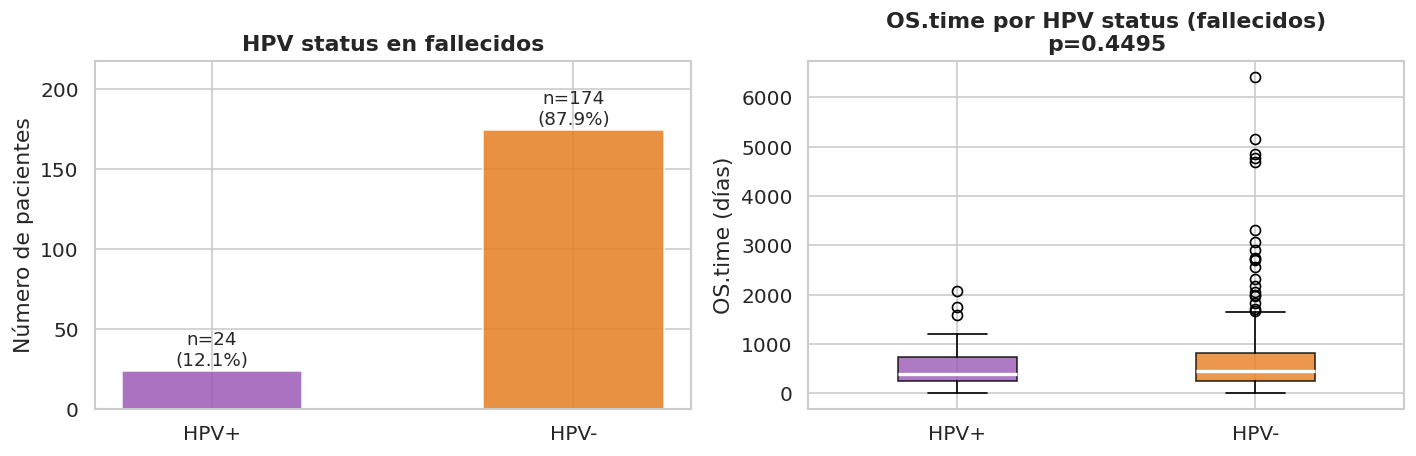

In [ ]:
# ── Distribución HPV en fallecidos ────────────────────────────────────
hpv_dead       = hpv_values[dead_mask]
n_hpv_pos_dead = int((hpv_dead == 1).sum())
n_hpv_neg_dead = int((hpv_dead == 0).sum())
n_dead_total   = len(dead_indices)

os_hpv_pos = os_time_np[dead_mask][hpv_dead == 1]
os_hpv_neg = os_time_np[dead_mask][hpv_dead == 0]

print('=' * 52)
print('  HPV STATUS EN FALLECIDOS')
print('=' * 52)
print(f'  Total fallecidos : {n_dead_total}')
print(f'  HPV+             : {n_hpv_pos_dead}  ({n_hpv_pos_dead/n_dead_total*100:.1f}%)')
print(f'  HPV-             : {n_hpv_neg_dead}  ({n_hpv_neg_dead/n_dead_total*100:.1f}%)')
print()
print('  OS.time (días) por grupo:')
print(f'  HPV+  media={os_hpv_pos.mean():.0f}d  mediana={np.median(os_hpv_pos):.0f}d  '
      f'rango={os_hpv_pos.min():.0f}–{os_hpv_pos.max():.0f}d')
print(f'  HPV-  media={os_hpv_neg.mean():.0f}d  mediana={np.median(os_hpv_neg):.0f}d  '
      f'rango={os_hpv_neg.min():.0f}–{os_hpv_neg.max():.0f}d')
print()

# Test Mann-Whitney HPV+ vs HPV- en OS.time
from scipy import stats as sp_stats
stat_mw, pval_mw = sp_stats.mannwhitneyu(os_hpv_pos, os_hpv_neg, alternative='two-sided')
print(f'  Mann-Whitney HPV+ vs HPV- en OS.time: p={pval_mw:.4f}')
print(f'  → HPV+ viven significativamente más antes de morir: {"Sí" if pval_mw < 0.05 else "No (p≥0.05)"}')
print('=' * 52)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# [0] Barplot HPV+ vs HPV-
ax = axes[0]
bars = ax.bar(['HPV+', 'HPV-'], [n_hpv_pos_dead, n_hpv_neg_dead],
               color=['#9b59b6', '#e67e22'], alpha=0.85, edgecolor='white', width=0.5)
for bar, n in zip(bars, [n_hpv_pos_dead, n_hpv_neg_dead]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={n}\n({n/n_dead_total*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Número de pacientes')
ax.set_title('HPV status en fallecidos', fontweight='bold')
ax.set_ylim(0, max(n_hpv_pos_dead, n_hpv_neg_dead) * 1.25)

# [1] Boxplot OS.time por HPV
ax = axes[1]
bp = ax.boxplot([os_hpv_pos, os_hpv_neg], labels=['HPV+', 'HPV-'],
                patch_artist=True, widths=0.4,
                medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('#9b59b6'); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor('#e67e22'); bp['boxes'][1].set_alpha(0.8)
ax.set_ylabel('OS.time (días)')
ax.set_title(f'OS.time por HPV status (fallecidos)\np={pval_mw:.4f}', fontweight='bold')

plt.tight_layout()
plt.show()

Análisis de la mediana del OS.time en fallecidos como umbral de clasificación.
Se fija el umbral en 450 días y se generan las etiquetas corta/larga.

═══════════════════════════════════════════════════════
ANÁLISIS DE LA MEDIANA — COHORTE FALLECIDOS
═══════════════════════════════════════════════════════

  n fallecidos    : 198
  Media           : 759.4 días (2.1 años)
  Mediana (Q2)    : 450.0 días (1.2 años)
  Q1 (25%)        : 259.5 días (0.7 años)
  Q3 (75%)        : 818.8 días (2.2 años)
  IQR             : 559.2 días
  Min             : 2.0 días
  Max             : 6417.0 días

  Corta (≤450d)  : n=99  media=246.1d  std=124.5d
  Larga (>450d)  : n=99  media=1272.7d  std=1132.9d

  Mann-Whitney p  : 5.45e-34
  KS test p       : 8.79e-59

  Balance clases  : 99/99 = 1.000 (1.0 = perfecto)


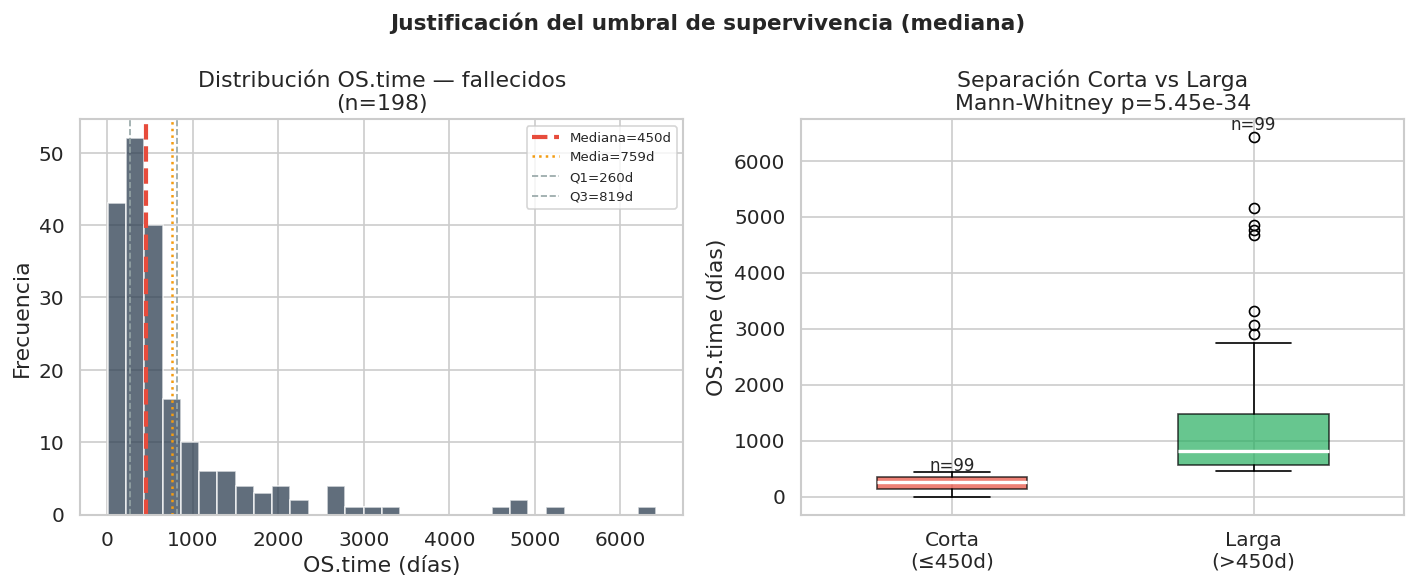

In [ ]:
# ── Análisis de la mediana como umbral de supervivencia ───────────────
from scipy.stats import mannwhitneyu, ks_2samp
import matplotlib.patches as mpatches

os_dead = os_time_np[dead_mask]

median_val = np.median(os_dead)
mean_val   = np.mean(os_dead)
q1         = np.percentile(os_dead, 25)
q3         = np.percentile(os_dead, 75)

print('═' * 55)
print('ANÁLISIS DE LA MEDIANA — COHORTE FALLECIDOS')
print('═' * 55)
print(f'\n  n fallecidos    : {len(os_dead)}')
print(f'  Media           : {mean_val:.1f} días ({mean_val/365:.1f} años)')
print(f'  Mediana (Q2)    : {median_val:.1f} días ({median_val/365:.1f} años)')
print(f'  Q1 (25%)        : {q1:.1f} días ({q1/365:.1f} años)')
print(f'  Q3 (75%)        : {q3:.1f} días ({q3/365:.1f} años)')
print(f'  IQR             : {q3-q1:.1f} días')
print(f'  Min             : {os_dead.min():.1f} días')
print(f'  Max             : {os_dead.max():.1f} días')

corta = os_dead[os_dead <= median_val]
larga = os_dead[os_dead >  median_val]

print(f'\n  Corta (≤{median_val:.0f}d)  : n={len(corta)}  media={corta.mean():.1f}d  std={corta.std():.1f}d')
print(f'  Larga (>{median_val:.0f}d)  : n={len(larga)}  media={larga.mean():.1f}d  std={larga.std():.1f}d')

stat_mw, p_mw = mannwhitneyu(corta, larga, alternative='two-sided')
stat_ks, p_ks = ks_2samp(corta, larga)
print(f'\n  Mann-Whitney p  : {p_mw:.2e}')
print(f'  KS test p       : {p_ks:.2e}')
print(f'\n  Balance clases  : {len(corta)}/{len(larga)} = {len(corta)/len(larga):.3f} (1.0 = perfecto)')

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# [0] Histograma con mediana
ax = axes[0]
ax.hist(os_dead, bins=30, color='#2c3e50', alpha=0.75, edgecolor='white')
ax.axvline(median_val, color='#e74c3c', lw=2.5, linestyle='--', label=f'Mediana={median_val:.0f}d')
ax.axvline(mean_val,   color='#f39c12', lw=1.5, linestyle=':',  label=f'Media={mean_val:.0f}d')
ax.axvline(q1,         color='#95a5a6', lw=1,   linestyle='--', label=f'Q1={q1:.0f}d')
ax.axvline(q3,         color='#95a5a6', lw=1,   linestyle='--', label=f'Q3={q3:.0f}d')
ax.set_xlabel('OS.time (días)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución OS.time — fallecidos\n(n=198)')
ax.legend(fontsize=8)

# [1] Boxplot Corta vs Larga
ax = axes[1]
bp = ax.boxplot([corta, larga], labels=[f'Corta\n(≤{median_val:.0f}d)', f'Larga\n(>{median_val:.0f}d)'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#e74c3c'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#27ae60'); bp['boxes'][1].set_alpha(0.7)
for median_line in bp['medians']:
    median_line.set_color('white'); median_line.set_linewidth(2)
ax.set_ylabel('OS.time (días)')
ax.set_title(f'Separación Corta vs Larga\nMann-Whitney p={p_mw:.2e}')
for i, (grupo, n) in enumerate([(corta, len(corta)), (larga, len(larga))], 1):
    ax.text(i, grupo.max()*1.02, f'n={n}', ha='center', fontsize=10)

plt.suptitle('Justificación del umbral de supervivencia (mediana)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1. Optuna: búsqueda de hiperparámetros

Optimización automática de hiperparámetros

25 trials × 500 épocas × parada temprana de 150 épocas.


Definición de etiquetas binarias para todos los pacientes del grafo
(NaN para censurados) y cálculo de índices de fallecidos.

In [ ]:
# ── Etiquetas por mediana — todos los fallecidos ──────────────────────
MEDIAN_THR = float(np.median(os_time_np[dead_mask]))
print(f'Mediana OS.time fallecidos: {MEDIAN_THR:.0f} días')

# Labels para todos los pacientes del grafo (NaN = censurados)
labels_all = torch.full((n_patients,), float('nan'))
for i in range(n_patients):
    if os_event_np[i] == 1:   # solo fallecidos
        if os_time_np[i] <= MEDIAN_THR:
            labels_all[i] = 0.0   # supervivencia corta
        else:
            labels_all[i] = 1.0   # supervivencia larga

# Índices de todos los fallecidos (todos participan)
q14_indices = np.where(~torch.isnan(labels_all).numpy())[0]

n_corta = int((labels_all == 0).sum().item())
n_larga = int((labels_all == 1).sum().item())
print(f'Supervivencia corta (≤{MEDIAN_THR:.0f}d): {n_corta}')
print(f'Supervivencia larga (>{MEDIAN_THR:.0f}d) : {n_larga}')
print(f'Total fallecidos en entrenamiento   : {len(q14_indices)}')

# HPV en cada grupo
hpv_corta = hpv_values[q14_indices[labels_all[q14_indices].numpy() == 0]]
hpv_larga = hpv_values[q14_indices[labels_all[q14_indices].numpy() == 1]]
print(f'HPV+ corta: {(hpv_corta==1).sum()} | HPV+ larga: {(hpv_larga==1).sum()}')


Mediana OS.time fallecidos: 450 días
Supervivencia corta (≤450d): 99
Supervivencia larga (>450d) : 99
Total fallecidos en entrenamiento   : 198
HPV+ corta: 14 | HPV+ larga: 10


Configuración y ejecución de Optuna.
Se define el objetivo, el espacio de búsqueda y el estudio con MedianPruner.

In [ ]:
import optuna
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

base_config_kwargs = dict(
    num_mirna    = n_mirna,
    num_mrna     = n_isoform,
    num_patients = n_patients,
)

objective = make_optuna_objective_classifier(
    data                      = graph_all,
    labels                    = labels_all,
    q14_indices               = q14_indices,
    base_config_kwargs        = base_config_kwargs,
    hpv                       = hpv_tensor,
    num_epochs_trial          = 500,
    early_stop_patience_trial = 150,
    n_folds                   = 4,
    seed                      = SEED,
)

study = optuna.create_study(
    direction  = 'minimize',
    pruner     = MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    study_name = 'supragraphnet_v8_focal',
)

print('🔍 Iniciando Optuna clasificación Corta vs Larga — mediana (25 trials × 500 epochs × 4 folds)...')
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f'\n✅ Optuna completado')
print(f'   Mejor AUC_val (media 4 folds): {1 - study.best_value:.4f}')
print(f'   Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'     {k}: {v}')

🔍 Iniciando Optuna clasificación Corta vs Larga — mediana (25 trials × 500 epochs × 4 folds)...


  0%|          | 0/25 [00:00<?, ?it/s]

  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  160/500  loss 0.1591  AUC 0.483
  ⏹️  Early stopping en época 160  |  mejor AUC: 0.6560
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  165/500  loss 0.1584  AUC 0.480
  ⏹️  Early stopping en época 165  |  mejor AUC: 0.5616
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  150/500  loss 0.1574  AUC 0.360
  ⏹️  Early stopping en época 150  |  mejor AUC: 0.5783
  [███████████░░░░░░░░░░░░░░░░░░░] ep  185/500  loss 0.1568  AUC 0.353
  ⏹️  Early stopping en época 185  |  mejor AUC: 0.4500
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  165/500  loss 0.0503  AUC 0.500
  ⏹️  Early stopping en época 165  |  mejor AUC: 0.6032
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  155/500  loss 0.0493  AUC 0.424
  ⏹️  Early stopping en época 155  |  mejor AUC: 0.5504
  [█████████░░░░░░░░░░░░░░░░░░░░░] ep  155/500  loss 0.0502  AUC 0.437
  ⏹️  Early stopping en época 155  |  mejor AUC: 0.6533
  [███████████████░░░░░░░░░░░░░░░] ep  260/500  loss 0.0498  AUC 0.478
  ⏹️  Early stopping en época 260  |  me

Construcción de la configuración óptima con los mejores hiperparámetros de Optuna.

In [ ]:
# ── Construir config con mejores hiperparámetros de Optuna ──────────
best_params = study.best_params

best_config = SupraGraphNetConfig(
    num_mirna      = n_mirna,
    num_mrna       = n_isoform,
    num_patients   = n_patients,
    hidden_dim     = best_params['hidden_dim'],
    heads          = best_params['heads'],
    dropout        = best_params['dropout'],
    expr_embed_dim = best_params['expr_embed_dim'],
    hpv_embed_dim  = best_params['hpv_embed_dim'],
)

TRAIN_LR             = best_params['lr']
TRAIN_WEIGHT_DECAY   = best_params['weight_decay']
TRAIN_NOISE_STD      = best_params['noise_std']
TRAIN_FOCAL_GAMMA    = best_params['focal_gamma']
TRAIN_LABEL_SMOOTHING= best_params['label_smoothing']

print('Config final (Optuna):')
print(f'  hidden_dim={best_config.hidden_dim}  heads={best_config.heads}  dropout={best_config.dropout:.4f}')
print(f'  expr_embed_dim={best_config.expr_embed_dim}  hpv_embed_dim={best_config.hpv_embed_dim}')
print(f'  lr={TRAIN_LR:.2e}  wd={TRAIN_WEIGHT_DECAY:.2e}  noise_std={TRAIN_NOISE_STD:.4f}')
print(f'  focal_gamma={TRAIN_FOCAL_GAMMA:.3f}  label_smoothing={TRAIN_LABEL_SMOOTHING:.3f}')

Config final (Optuna):
  hidden_dim=64  heads=2  dropout=0.4587
  expr_embed_dim=64  hpv_embed_dim=16
  lr=2.36e-04  wd=1.33e-02  noise_std=0.0475
  focal_gamma=1.615  label_smoothing=0.084


## 2. Entrenamiento K-Fold sobre fallecidos

4-Fold estratificado por label (corta/larga) sobre los 198 fallecidos.
~148 pacientes en train y ~50 en val por fold.
Optimizador AdamW con planificador de coseno. Parada temprana de 400 épocas.
Cada fold se repite hasta 3 veces conservando el mejor modelo por AUC.
Se guarda el mejor modelo global y el índice del mejor fold.

Entrenamiento K-Fold con los hiperparámetros óptimos.
Se guarda el mejor modelo global y las métricas de cada fold.

In [ ]:
import gc
from sklearn.model_selection import StratifiedKFold

N_FOLDS        = 4
NUM_EPOCHS     = 1000
EARLY_STOP     = 400
MAX_RETRIES    = 3
AUC_RETRY_THR  = 0.55

# ── Parámetros de Optuna ──────────────────────────────────────────────
best_params = study.best_params

best_config = SupraGraphNetConfig(
    num_mirna      = n_mirna,
    num_mrna       = n_isoform,
    num_patients   = n_patients,
    hidden_dim     = best_params['hidden_dim'],
    heads          = best_params['heads'],
    os_head_dim    = 16,
    dropout        = best_params['dropout'],
    expr_embed_dim = best_params['expr_embed_dim'],
    hpv_embed_dim  = best_params['hpv_embed_dim'],
)

TRAIN_LR              = best_params['lr']
TRAIN_WEIGHT_DECAY    = best_params['weight_decay']
TRAIN_NOISE_STD       = best_params['noise_std']
TRAIN_FOCAL_GAMMA     = best_params['focal_gamma']
TRAIN_LABEL_SMOOTHING = best_params['label_smoothing']

print('Config final (Optuna):')
print(f'  hidden_dim={best_config.hidden_dim}  heads={best_config.heads}  os_head_dim=16 (forzado)')
print(f'  dropout={best_config.dropout:.4f}  expr_embed_dim={best_config.expr_embed_dim}  hpv_embed_dim={best_config.hpv_embed_dim}')
print(f'  lr={TRAIN_LR:.2e}  wd={TRAIN_WEIGHT_DECAY:.2e}  noise_std={TRAIN_NOISE_STD:.4f}')
print(f'  focal_gamma={TRAIN_FOCAL_GAMMA:.3f}  label_smoothing={TRAIN_LABEL_SMOOTHING:.3f}')

# ── K-Fold estratificado por label corta/larga ────────────────────────
labels_q14 = labels_all[q14_indices].numpy().astype(int)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_metrics    = []
fold_models     = []
fold_train_hist = []
fold_val_hist   = []

best_auc_global = 0.0
best_model      = None
best_fold_idx   = -1
best_state      = None

for fold, (train_rel, val_rel) in enumerate(
    skf.split(q14_indices, labels_q14), start=1
):
    train_idx = q14_indices[train_rel]
    val_idx   = q14_indices[val_rel]

    print(f'\n{"="*55}')
    print(f'  FOLD {fold}/{N_FOLDS}  |  train: {len(train_idx)} | val: {len(val_idx)}')
    print(f'  Corta train: {(labels_all[train_idx]==0).sum().item()} | '
          f'Larga train: {(labels_all[train_idx]==1).sum().item()}')
    print(f'{"="*55}')

    best_fold_auc     = 0.0
    best_fold_model   = None
    best_fold_metrics = None

    for retry in range(MAX_RETRIES):
        torch.manual_seed(SEED + fold * 10 + retry)
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        model_fold, metrics_fold = train_supra_graph_classifier(
            data                = graph_all,
            labels              = labels_all,
            train_idx           = train_idx,
            val_idx             = val_idx,
            config              = best_config,
            hpv                 = hpv_tensor,
            num_epochs          = NUM_EPOCHS,
            lr                  = TRAIN_LR,
            weight_decay        = TRAIN_WEIGHT_DECAY,
            early_stop_patience = EARLY_STOP,
            noise_std           = TRAIN_NOISE_STD,
            focal_gamma         = TRAIN_FOCAL_GAMMA,
            label_smoothing     = TRAIN_LABEL_SMOOTHING,
        )

        auc_v = metrics_fold['val_auc']
        print(f'  → Intento {retry+1}: AUC={auc_v:.4f}')

        if auc_v > best_fold_auc:
            best_fold_auc     = auc_v
            best_fold_model   = model_fold
            best_fold_metrics = metrics_fold

        if auc_v >= AUC_RETRY_THR:
            break

    fold_metrics.append(best_fold_metrics)
    fold_models.append(best_fold_model)
    fold_train_hist.append(best_fold_metrics['train_history'])
    fold_val_hist.append(best_fold_metrics['val_history'])

    if best_fold_auc > best_auc_global:
        best_auc_global = best_fold_auc
        best_model      = best_fold_model
        best_fold_idx   = fold
        best_state      = {k: v.cpu().clone() for k, v in best_fold_model.state_dict().items()}

    print(f'   Fold {fold} — AUC={best_fold_auc:.4f}')

aucs = [m['val_auc'] for m in fold_metrics]
print(f'\n  Mejor fold: {best_fold_idx} — AUC={best_auc_global:.4f}')
print(f'  AUC media K-Fold: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')

# ── Umbral de Youden sobre el mejor fold ─────────────────────────────
from sklearn.metrics import roc_curve

best_m_tmp = fold_metrics[best_fold_idx - 1]
fpr_y, tpr_y, thr_y = roc_curve(
    best_m_tmp['val_labels'].astype(int),
    best_m_tmp['val_probs']
)
youden_idx     = int(np.argmax(tpr_y - fpr_y))
BEST_THRESHOLD = float(thr_y[youden_idx])

print(f'\n  Umbral óptimo (Youden): {BEST_THRESHOLD:.4f}')
print(f'    TPR (Sensibilidad) = {tpr_y[youden_idx]:.4f}')
print(f'    FPR (1-Especif.)   = {fpr_y[youden_idx]:.4f}')
print(f'    Índice de Youden   = {tpr_y[youden_idx] - fpr_y[youden_idx]:.4f}')

Config final (Optuna):
  hidden_dim=64  heads=2  os_head_dim=16 (forzado)
  dropout=0.4587  expr_embed_dim=64  hpv_embed_dim=16
  lr=2.36e-04  wd=1.33e-02  noise_std=0.0475
  focal_gamma=1.615  label_smoothing=0.084

  FOLD 1/4  |  train: 148 | val: 50
  Corta train: 74 | Larga train: 74
  [█████████████████████████░░░░░] ep  835/1000  loss 0.2083  AUC 0.686
  ⏹️  Early stopping en época 835  |  mejor AUC: 0.7136
  → Intento 1: AUC=0.7136
  ✅ Fold 1 — AUC=0.7136

  FOLD 2/4  |  train: 148 | val: 50
  Corta train: 74 | Larga train: 74
  [████████████████░░░░░░░░░░░░░░] ep  560/1000  loss 0.2018  AUC 0.584
  ⏹️  Early stopping en época 560  |  mejor AUC: 0.6592
  → Intento 1: AUC=0.6592
  ✅ Fold 2 — AUC=0.6592

  FOLD 3/4  |  train: 149 | val: 49
  Corta train: 75 | Larga train: 74
  [███████████████████░░░░░░░░░░░] ep  635/1000  loss 0.2039  AUC 0.462
  ⏹️  Early stopping en época 635  |  mejor AUC: 0.5417
  → Intento 1: AUC=0.5417
  [████████████░░░░░░░░░░░░░░░░░░] ep  400/1000  loss 0

## 3. Métricas y evaluación del modelo

AUC-ROC (métrica principal, media ± std sobre 4 folds), F1 macro, accuracy,
sensibilidad y precisión por clase (corta y larga).
El umbral de clasificación se determina mediante el índice de Youden
(J = TPR − FPR) sobre la curva ROC del mejor fold, maximizando
simultáneamente sensibilidad y especificidad de forma reproducible.

Resumen numérico: AUC media y por fold.

In [ ]:
aucs = [m['val_auc'] for m in fold_metrics]

print('=' * 55)
print('📊 RESUMEN FINAL K-FOLD — HNSC v8')
print('=' * 55)
print(f'  AUC  →  media: {np.mean(aucs):.4f}  ±  {np.std(aucs):.4f}')
print(f'  Mejor AUC: {best_auc_global:.4f} (Fold {best_fold_idx})')
print()
for i, m in enumerate(fold_metrics, 1):
    marker = ' ← mejor' if i == best_fold_idx else ''
    print(f'  Fold {i}: AUC={m["val_auc"]:.4f}{marker}')

📊 RESUMEN FINAL K-FOLD — HNSC v8
  AUC  →  media: 0.6526  ±  0.0450
  Mejor AUC: 0.7120 (Fold 1)

  Fold 1: AUC=0.7120 ← mejor
  Fold 2: AUC=0.6800
  Fold 3: AUC=0.6050
  Fold 4: AUC=0.6133


Diagnóstico de la distribución de probabilidades predichas
sobre todos los fallecidos. Separación entre corta y larga.

══════════════════════════════════════════════════
DIAGNÓSTICO — Probabilidades predichas
══════════════════════════════════════════════════

Todos los fallecidos (n=198):
  min=0.139  max=0.643  media=0.492  std=0.061

Corta (label=0, n=99):
  media=0.476  std=0.075
Larga (label=1, n=99):
  media=0.508  std=0.035

Mann-Whitney p=0.0001 — SÍ hay separación


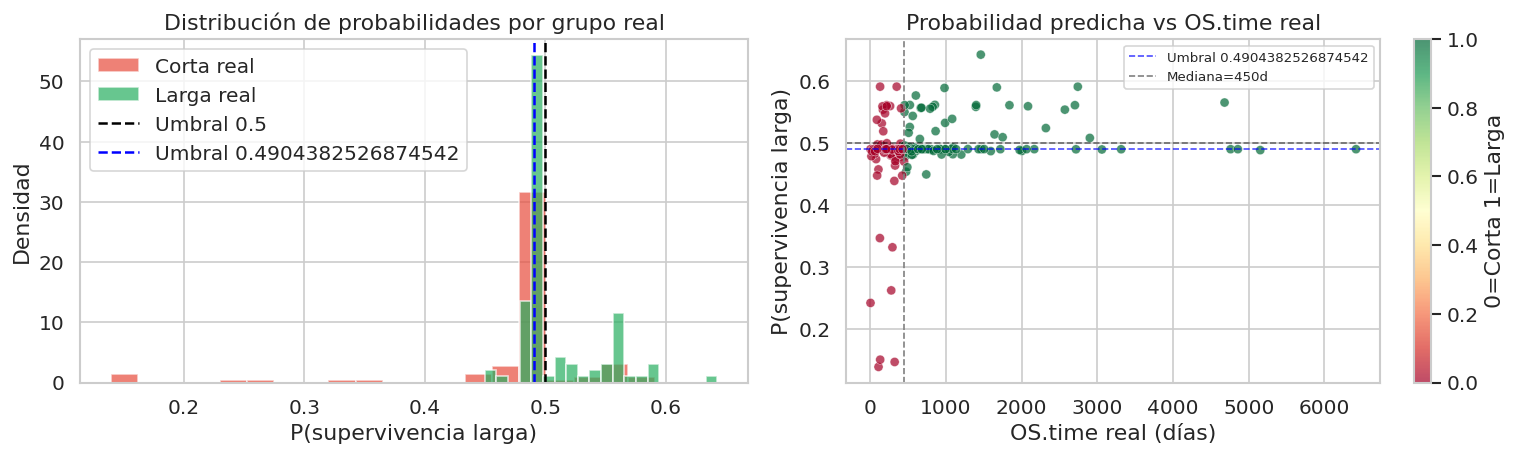

In [ ]:
# ── Diagnóstico: distribución de probabilidades ───────────────────────
best_model.eval()
with torch.no_grad():
    logits_diag = best_model(graph_all.to(device), hpv=hpv_tensor.to(device)).cpu()

probs_diag = torch.sigmoid(logits_diag).numpy()
labels_np  = labels_all.numpy()

probs_dead = probs_diag[q14_indices]
labels_dead = labels_np[q14_indices].astype(int)

print('═' * 50)
print('DIAGNÓSTICO — Probabilidades predichas')
print('═' * 50)
print(f'\nTodos los fallecidos (n={len(probs_dead)}):')
print(f'  min={probs_dead.min():.3f}  max={probs_dead.max():.3f}  media={probs_dead.mean():.3f}  std={probs_dead.std():.3f}')
print(f'\nCorta (label=0, n={(labels_dead==0).sum()}):')
print(f'  media={probs_dead[labels_dead==0].mean():.3f}  std={probs_dead[labels_dead==0].std():.3f}')
print(f'Larga (label=1, n={(labels_dead==1).sum()}):')
print(f'  media={probs_dead[labels_dead==1].mean():.3f}  std={probs_dead[labels_dead==1].std():.3f}')

from scipy.stats import mannwhitneyu
_, pval = mannwhitneyu(probs_dead[labels_dead==0], probs_dead[labels_dead==1], alternative='two-sided')
print(f'\nMann-Whitney p={pval:.4f} — {"SÍ hay separación" if pval < 0.05 else "NO hay separación significativa"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(probs_dead[labels_dead==0], bins=20, alpha=0.7, color='#e74c3c', label='Corta real', density=True)
ax.hist(probs_dead[labels_dead==1], bins=20, alpha=0.7, color='#27ae60', label='Larga real', density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Umbral 0.5')
ax.axvline(BEST_THRESHOLD, color='blue', linestyle='--', lw=1.5, label=f'Umbral {BEST_THRESHOLD}')
ax.set_xlabel('P(supervivencia larga)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades por grupo real')
ax.legend()

ax = axes[1]
sc = ax.scatter(os_time_np[q14_indices], probs_dead,
                c=labels_dead, cmap='RdYlGn', s=30, alpha=0.7,
                edgecolors='white', lw=0.3)
ax.axhline(0.5, color='black', linestyle='--', lw=1, alpha=0.5)
ax.axhline(BEST_THRESHOLD, color='blue', linestyle='--', lw=1, alpha=0.7, label=f'Umbral {BEST_THRESHOLD}')
ax.axvline(MEDIAN_THR, color='gray', linestyle='--', lw=1, label=f'Mediana={MEDIAN_THR:.0f}d')
ax.set_xlabel('OS.time real (días)')
ax.set_ylabel('P(supervivencia larga)')
ax.set_title('Probabilidad predicha vs OS.time real')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='0=Corta 1=Larga')

plt.tight_layout()
plt.show()

Determinación del umbral óptimo de Youden sobre la curva ROC del mejor fold.

Umbral óptimo (Youden) : 0.4904
  Sensibilidad (TPR)   : 0.6400
  1-Especificidad (FPR): 0.2000
  Índice de Youden (J) : 0.4400
  AUC (invariante)     : 0.7120


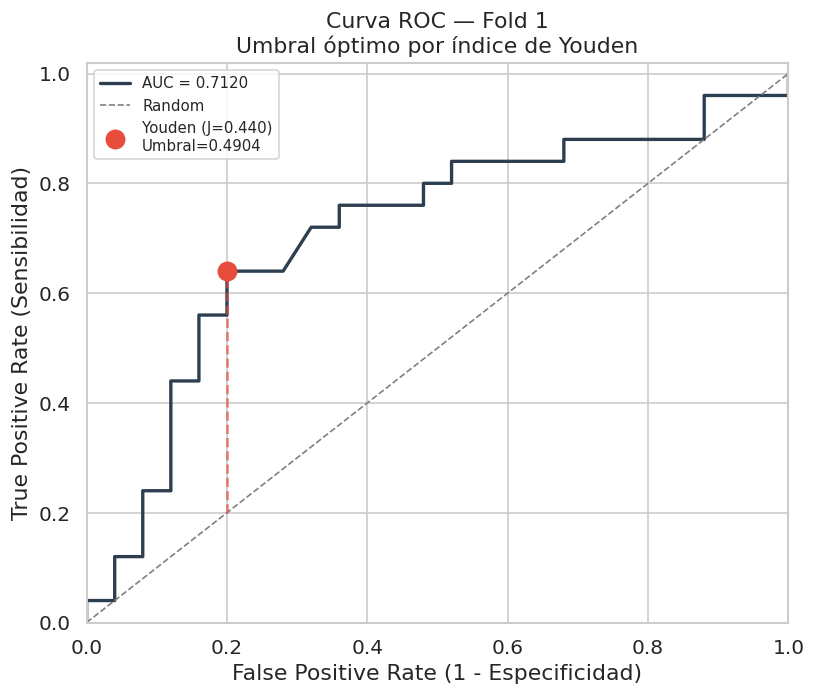

In [ ]:
# ── Umbral de Youden — visualización sobre curva ROC ─────────────────
from sklearn.metrics import roc_curve

best_m    = fold_metrics[best_fold_idx - 1]
fpr_y, tpr_y, thr_y = roc_curve(
    best_m['val_labels'].astype(int),
    best_m['val_probs']
)
youden_idx = int(np.argmax(tpr_y - fpr_y))

print(f'Umbral óptimo (Youden) : {BEST_THRESHOLD:.4f}')
print(f'  Sensibilidad (TPR)   : {tpr_y[youden_idx]:.4f}')
print(f'  1-Especificidad (FPR): {fpr_y[youden_idx]:.4f}')
print(f'  Índice de Youden (J) : {tpr_y[youden_idx] - fpr_y[youden_idx]:.4f}')
print(f'  AUC (invariante)     : {best_m["val_auc"]:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_y, tpr_y, color='#2c3e50', lw=2, label=f'AUC = {best_m["val_auc"]:.4f}')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')

# Punto de Youden
ax.scatter(fpr_y[youden_idx], tpr_y[youden_idx],
           color='#e74c3c', s=120, zorder=5,
           label=f'Youden (J={tpr_y[youden_idx]-fpr_y[youden_idx]:.3f})\n'
                 f'Umbral={BEST_THRESHOLD:.4f}')

# Línea vertical desde el punto al eje
ax.plot([fpr_y[youden_idx], fpr_y[youden_idx]], [fpr_y[youden_idx], tpr_y[youden_idx]],
        color='#e74c3c', linestyle='--', lw=1.5, alpha=0.7)

ax.set_xlabel('False Positive Rate (1 - Especificidad)')
ax.set_ylabel('True Positive Rate (Sensibilidad)')
ax.set_title(f'Curva ROC — Fold {best_fold_idx}\nUmbral óptimo por índice de Youden')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


Comparativa entre el umbral por defecto (0.5) y el umbral de Youden.

In [ ]:
# ── Comparativa: umbral 0.5 (defecto) vs umbral de Youden ────────────
from sklearn.metrics import f1_score, recall_score, precision_score

best_m     = fold_metrics[best_fold_idx - 1]
probs_val  = best_m['val_probs']
labels_val = best_m['val_labels'].astype(int)

print('Comparativa de umbrales — Fold', best_fold_idx)
print('─' * 60)
for thr, label in [(0.50, 'Defecto  (0.50)'),
                   (BEST_THRESHOLD, f'Youden   ({BEST_THRESHOLD:.4f})')]:
    preds     = (probs_val >= thr).astype(int)
    f1_macro  = f1_score(labels_val, preds, average='macro',  zero_division=0)
    rec_corta = recall_score(labels_val, preds, pos_label=0,  zero_division=0)
    rec_larga = recall_score(labels_val, preds, pos_label=1,  zero_division=0)
    prec_c    = precision_score(labels_val, preds, pos_label=0, zero_division=0)
    prec_l    = precision_score(labels_val, preds, pos_label=1, zero_division=0)
    print(f'{label}: F1={f1_macro:.3f}  '
          f'Rec_Corta={rec_corta:.3f}  Rec_Larga={rec_larga:.3f}  '
          f'Prec_Corta={prec_c:.3f}  Prec_Larga={prec_l:.3f}')

print()
print('Criterio: índice de Youden (J = TPR − FPR) sobre la curva ROC.')
print('Referencia: Youden WJ. Cancer. 1950;3(1):32-35.')


Comparativa de umbrales — Fold 1
────────────────────────────────────────────────────────────
Defecto  (0.50): F1=0.538  Rec_Corta=0.880  Rec_Larga=0.280  Prec_Corta=0.550  Prec_Larga=0.700
Youden   (0.4904): F1=0.718  Rec_Corta=0.800  Rec_Larga=0.640  Prec_Corta=0.690  Prec_Larga=0.762

Criterio: índice de Youden (J = TPR − FPR) sobre la curva ROC.
Referencia: Youden WJ. Cancer. 1950;3(1):32-35.


Evaluación final del modelo con el umbral de Youden:
AUC, F1 macro, accuracy, sensibilidad y precisión por clase.

═══════════════════════════════════════════════════════
  EVALUACIÓN FINAL — Fold 1 | Umbral 0.4904382526874542
═══════════════════════════════════════════════════════
  AUC        : 0.7120  (invariante al umbral)
  Accuracy   : 0.7200
  F1 macro   : 0.7182



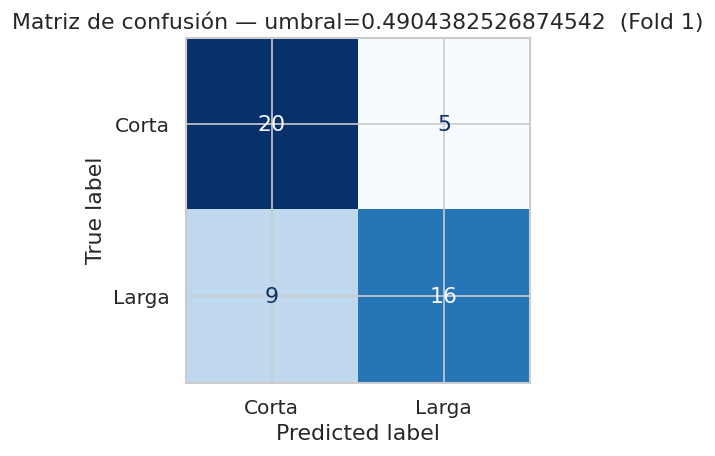

In [ ]:
# ── Evaluación final con umbral de Youden ───────────────────────
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score,
                             recall_score, precision_score)

best_m    = fold_metrics[best_fold_idx - 1]
preds_opt = (best_m['val_probs'] >= BEST_THRESHOLD).astype(int)
labels_v  = best_m['val_labels'].astype(int)

f1_macro  = f1_score(labels_v, preds_opt, average='macro',  zero_division=0)
f1_corta  = f1_score(labels_v, preds_opt, pos_label=0,      zero_division=0)
f1_larga  = f1_score(labels_v, preds_opt, pos_label=1,      zero_division=0)
rec_corta = recall_score(labels_v, preds_opt, pos_label=0,  zero_division=0)
rec_larga = recall_score(labels_v, preds_opt, pos_label=1,  zero_division=0)
prec_corta= precision_score(labels_v, preds_opt, pos_label=0, zero_division=0)
prec_larga= precision_score(labels_v, preds_opt, pos_label=1, zero_division=0)
accuracy  = (preds_opt == labels_v).mean()

print('═' * 55)
print(f'  EVALUACIÓN FINAL — Fold {best_fold_idx} | Umbral {BEST_THRESHOLD}')
print('═' * 55)
print(f'  AUC        : {best_m["val_auc"]:.4f}  (invariante al umbral)')
print(f'  Accuracy   : {accuracy:.4f}')
print(f'  F1 macro   : {f1_macro:.4f}')
print()


cm = confusion_matrix(labels_v, preds_opt)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Corta', 'Larga']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — umbral={BEST_THRESHOLD}  (Fold {best_fold_idx})')
plt.tight_layout()
plt.show()

Curva ROC y matrices de confusión con ambos umbrales (0.5 vs Youden).

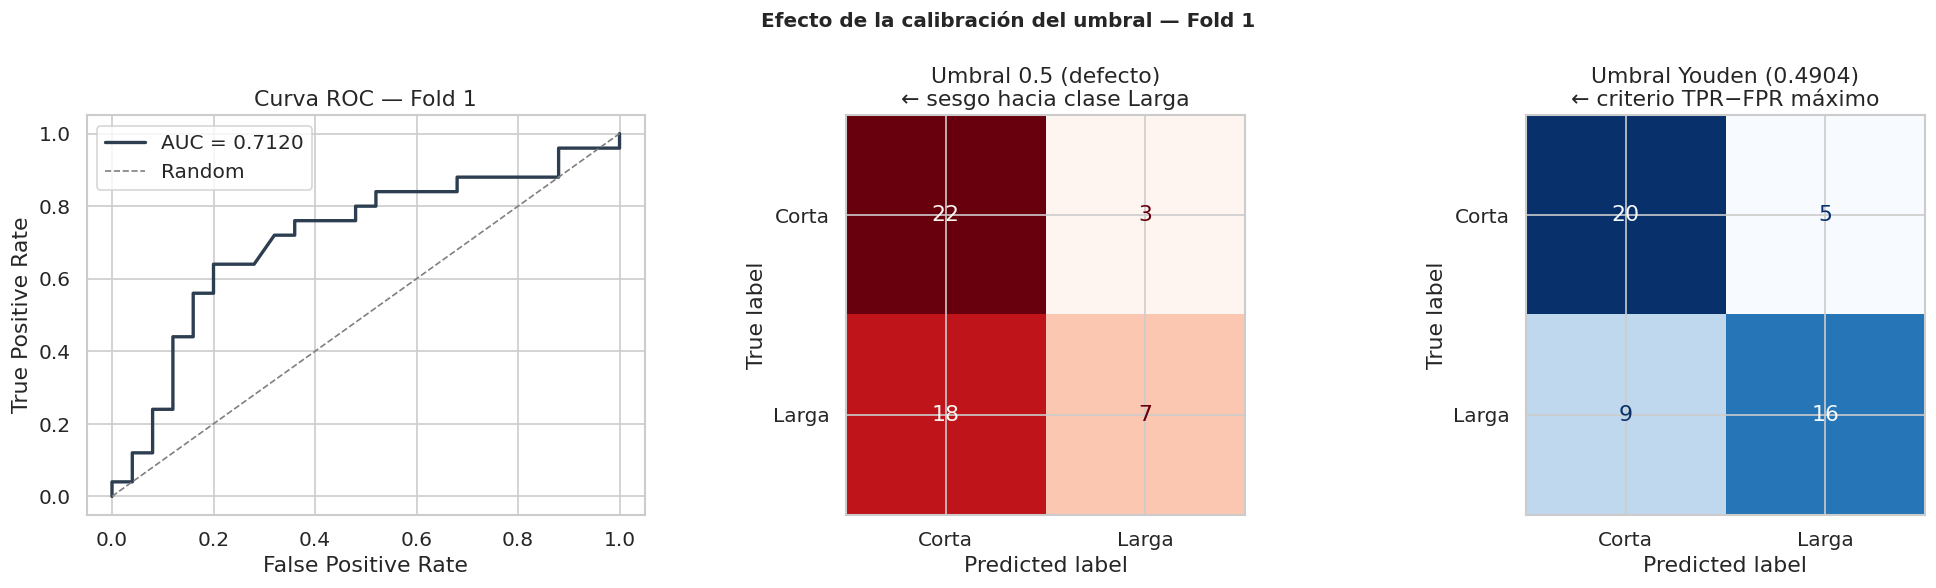

In [ ]:
# ── Curva ROC + Matrices de confusión (umbral 0.5 vs Youden) ────────
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

best_m = fold_metrics[best_fold_idx - 1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# [0] Curva ROC
fpr, tpr, _ = roc_curve(best_m['val_labels'], best_m['val_probs'])
axes[0].plot(fpr, tpr, color='#2c3e50', lw=2,
             label=f'AUC = {best_m["val_auc"]:.4f}')
axes[0].plot([0,1], [0,1], '--', color='gray', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Curva ROC — Fold {best_fold_idx}')
axes[0].legend()

# [1] Matriz umbral 0.5 (defecto)
preds_05 = (best_m['val_probs'] >= 0.5).astype(int)
cm_05    = confusion_matrix(best_m['val_labels'].astype(int), preds_05)
ConfusionMatrixDisplay(cm_05, display_labels=['Corta','Larga']).plot(
    ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title('Umbral 0.5 (defecto)\n← sesgo hacia clase Larga')

# [2] Matriz umbral Youden (calibrado)
preds_57 = (best_m['val_probs'] >= BEST_THRESHOLD).astype(int)
cm_57    = confusion_matrix(best_m['val_labels'].astype(int), preds_57)
ConfusionMatrixDisplay(cm_57, display_labels=['Corta','Larga']).plot(
    ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Umbral Youden ({BEST_THRESHOLD:.4f})\n← criterio TPR−FPR máximo')

plt.suptitle(f'Efecto de la calibración del umbral — Fold {best_fold_idx}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



## 4. GNNExplainer: importancia de nodos y aristas

Importancias por gradiente sobre los fallecidos del fold de validación
del mejor modelo. La importancia de cada nodo es la norma L1 del gradiente
de la predicción respecto a sus features, promediada sobre todos los pacientes
analizados y normalizada por z-score y escala min-max.
Análisis global y diferencial entre grupos (corta vs larga) mediante log₂-ratio.
Nodos con z > 2σ se consideran genuinamente destacados.

Identificación de los índices de fallecidos del fold de validación
del mejor modelo, separados por grupo corta y larga.

In [ ]:
# ── Índices fallecidos del mejor fold val ────────────────────────────
splits_list     = list(skf.split(q14_indices, labels_q14))
_, val_rel_best = splits_list[best_fold_idx - 1]
val_idx_best    = q14_indices[val_rel_best]

# Separar corta y larga
q1_val = val_idx_best[labels_all[val_idx_best].numpy() == 0]   # corta
q4_val = val_idx_best[labels_all[val_idx_best].numpy() == 1]   # larga

print(f'Val mejor fold — total: {len(val_idx_best)} | Corta: {len(q1_val)} | Larga: {len(q4_val)}')
print(f'OS.time corta — media: {os_time_np[q1_val].mean():.0f}d  '
      f'rango: {os_time_np[q1_val].min():.0f}–{os_time_np[q1_val].max():.0f}d')
print(f'OS.time larga — media: {os_time_np[q4_val].mean():.0f}d  '
      f'rango: {os_time_np[q4_val].min():.0f}–{os_time_np[q4_val].max():.0f}d')


Val mejor fold — total: 50 | Corta: 25 | Larga: 25
OS.time corta — media: 315d  rango: 32–436d
OS.time larga — media: 1173d  rango: 451–6417d


Carga del mapeo MIMAT → nombre canónico de miRNA (miRBase).

In [ ]:
# ── Mapeo MIMAT → nombre legible ──────────────────────────────────────
from hnsc_graph.graph_construction import build_mimat_name_maps

mature_fa_path = Path('data/mature.fa')
mimat_to_name, _ = build_mimat_name_maps(mature_fa_path)

print(f'mimat_to_name: {len(mimat_to_name)} entradas')
print('Ejemplo:', list(mimat_to_name.items())[:3])

miRBase: 2656 entradas hsa cargadas


mimat_to_name: 2656 entradas
Ejemplo: [('MIMAT0000062', 'hsa-let-7a-5p'), ('MIMAT0004481', 'hsa-let-7a-3p'), ('MIMAT0010195', 'hsa-let-7a-2-3p')]


Construcción del diccionario isoforma → símbolo génico
mediante el archivo RSEM de genes.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Limpiamos los IDs del grafo (quitamos versiones .1, .2 para asegurar match)
isoform_ids_grafo = set(graph_all['isoform'].node_ids)
# Diccionario auxiliar: { 'uc002wva': 'uc002wva.2' }
clean_to_original = {iso.split('.')[0]: iso for iso in isoform_ids_grafo}

isoform_to_gene = {}
# Usamos el archivo de GENES porque es el que contiene los Símbolos (SÓLO ESTE TIENE EL NOMBRE DEL GEN)
rsem_gene_file = Path('data/HNSC.rnaseqv2__illuminahiseq_rnaseqv2__unc_edu__Level_3__RSEM_genes__data.data.txt')

if rsem_gene_file.exists():
    print(f"Analizando archivo de genes para mapeo...")
    # Leemos solo las primeras filas para detectar dónde está la columna de transcripts
    df_head = pd.read_csv(rsem_gene_file, sep='\t', nrows=2)

    # Buscamos en qué columna dice 'transcript_id' (suele ser la 1 o la 2)
    # En TCGA, la fila 1 (index 0 del df) contiene los nombres de los descriptores
    row_descriptors = df_head.iloc[0].astype(str).values
    transcript_col_idx = -1

    for i, desc in enumerate(row_descriptors):
        if 'transcript_id' in desc.lower():
            transcript_col_idx = i
            break

    if transcript_col_idx != -1:
        # Cargamos el archivo saltando la fila de pacientes, usando la 0 como nombres de genes
        # y la columna detectada como transcripts
        df_map = pd.read_csv(rsem_gene_file, sep='\t', skiprows=[0]) # Saltamos los códigos TCGA

        gene_col = df_map.columns[0]
        trans_col = df_map.columns[transcript_col_idx]

        for _, row in df_map.iterrows():
            raw_gene = str(row[gene_col])
            raw_transcripts = str(row[trans_col])

            # Limpiar nombre de gen: 'A1BG|1' -> 'A1BG'
            gene_symbol = raw_gene.split('|')[0] if '|' in raw_gene else raw_gene
            if gene_symbol in ['?', 'nan', 'Hybridization REF']: continue

            # Las isoformas vienen separadas por coma: 'uc001abc.1,uc001def.1'
            for iso in raw_transcripts.split(','):
                iso = iso.strip()
                iso_clean = iso.split('.')[0]

                # Intentar match directo
                if iso in isoform_ids_grafo:
                    isoform_to_gene[iso] = gene_symbol
                # Intentar match sin versión (.1, .2)
                elif iso_clean in clean_to_original:
                    original_id = clean_to_original[iso_clean]
                    isoform_to_gene[original_id] = gene_symbol

    print(f'--- RESULTADOS FINALES ---')
    print(f'Isoformas en grafo: {len(isoform_ids_grafo)}')
    print(f'Mapeos encontrados: {len(isoform_to_gene)}')

    if isoform_to_gene:
        print("\nEjemplos recuperados:")
        for i, (k, v) in enumerate(isoform_to_gene.items()):
            print(f"  {k} -> {v}")
            if i > 5: break
else:
    print("No se encontró el archivo de genes RSEM.")

Analizando archivo de genes para mapeo...
--- RESULTADOS FINALES ---
Isoformas en grafo: 5305
Mapeos encontrados: 5230

Ejemplos recuperados:
  uc001quz.3 -> A2ML1
  uc010sgm.1 -> A2ML1
  uc010gzd.2 -> A4GALT
  uc010yqm.1 -> AAK1
  uc001pjd.1 -> AASDHPPT
  uc003hbn.2 -> AASDH
  uc011cab.1 -> AASDH


Ejecución del GNNExplainer por gradiente sobre los fallecidos
del fold de validación del mejor modelo.

In [ ]:
# ── Correr GNNExplainer ───────────────────────────────────────────────
print(f'Calculando importancias sobre {len(val_idx_best)} pacientes ...')

explainer_results = run_gnnexplainer(
    model           = best_model,
    data            = graph_all,
    patient_indices = list(val_idx_best),   # ← antes dead_val_best
    hpv             = hpv_tensor,
)

df_mirna_imp   = explainer_results['mirna_importance']
df_isoform_imp = explainer_results['isoform_importance']
df_edge_mm_imp = explainer_results['edge_mm_importance']
df_edge_mi_imp = explainer_results['edge_mi_importance']

# Añadir nombres
df_mirna_imp['mirna_name'] = df_mirna_imp['mirna_id'].map(mimat_to_name).fillna(df_mirna_imp['mirna_id'])
df_isoform_imp['gen']      = df_isoform_imp['isoform_id'].map(isoform_to_gene).fillna(df_isoform_imp['isoform_id'])

print(f'Top 10 miRNAs más importantes:')
print(df_mirna_imp[['mirna_name','mean_importance']].head(10).to_string(index=False))
print()
print(f'Top 10 isoformas/genes más importantes:')
print(df_isoform_imp[['gen','mean_importance']].head(10).to_string(index=False))

Calculando importancias sobre 50 pacientes ...
Top 10 miRNAs más importantes:
       mirna_name  mean_importance
    hsa-miR-21-5p     4.009067e-05
  hsa-miR-203a-3p     9.141697e-06
   hsa-miR-143-3p     5.401067e-06
     hsa-miR-7704     1.756042e-06
    hsa-miR-22-3p     1.299021e-06
   hsa-miR-431-5p     1.217073e-06
hsa-miR-103a-2-5p     1.101373e-06
      hsa-miR-326     1.008619e-06
  hsa-miR-500a-5p     7.935910e-07
  hsa-miR-500b-5p     7.931125e-07

Top 10 isoformas/genes más importantes:
       gen  mean_importance
     KRT14         0.000330
     KRT13         0.000102
       NTS         0.000072
     GPNMB         0.000064
uc001yse.2         0.000040
      KRT4         0.000038
     KRT19         0.000038
     ADAM6         0.000007
    AKR1C1         0.000006
       PI3         0.000006


Corrección manual del mapeo para isoformas sin correspondencia génica directa.

In [ ]:
# ── Parche manual: isoformas sin mapear en isoform_to_gene ────────────
manual_fixes = {
    'uc001yse.2': 'IGHG1',
    # añade aquí más si aparecen otros IDs sin mapear
}

isoform_to_gene.update(manual_fixes)

# Reaplicar mapeo a los dataframes de importancia
df_isoform_imp['gen'] = df_isoform_imp['isoform_id'].map(isoform_to_gene).fillna(df_isoform_imp['isoform_id'])

print('Parche aplicado:')
for iso, gen in manual_fixes.items():
    print(f'  {iso} → {gen}')

print()
print('Top 10 genes tras parche:')
print(df_isoform_imp[['isoform_id','gen','mean_importance']].head(10).to_string(index=False))

Parche aplicado:
  uc001yse.2 → IGHG1

Top 10 genes tras parche:
isoform_id    gen  mean_importance
uc002hxf.1  KRT14         0.000330
uc002hwu.1  KRT13         0.000102
uc001tag.2    NTS         0.000072
uc003swb.2  GPNMB         0.000064
uc001yse.2  IGHG1         0.000040
uc001saz.2   KRT4         0.000038
uc002hxd.3  KRT19         0.000038
uc010tyt.1  ADAM6         0.000007
uc001ihq.2 AKR1C1         0.000006
uc002xng.2    PI3         0.000006


Normalización de las importancias globales por z-score y escala min-max.
Nodos con z > 2σ son candidatos con señal pronóstica destacada.

In [ ]:
# ── Normalización de importancias GNNExplainer ────────────────────────
# mean_importance es pequeño (0.000x) por dilución del gradiente sobre
# n_pacientes × 474 features. El RANKING es lo que importa biológicamente.

def normalizar_importancias(df, col='mean_importance'):
    df = df.copy()
    mn, mx = df[col].min(), df[col].max()
    # Min-Max [0,1] → para barplots
    df['imp_minmax']    = (df[col] - mn) / (mx - mn + 1e-12)
    # Z-score → para detectar outliers reales (z > 2σ = genuinamente importante)
    df['imp_zscore']    = (df[col] - df[col].mean()) / (df[col].std() + 1e-12)
    # Percentil [0-100] → para el TFM ("top X% del modelo")
    df['imp_percentil'] = df[col].rank(pct=True) * 100
    return df

df_mirna_imp   = normalizar_importancias(df_mirna_imp)
df_isoform_imp = normalizar_importancias(df_isoform_imp)

# ── Resumen ───────────────────────────────────────────────────────────
print('Top 10 miRNAs:')
print(df_mirna_imp[['mirna_name','mean_importance','imp_minmax','imp_zscore','imp_percentil']].head(10).to_string(index=False))
print()
print('Top 10 genes:')
print(df_isoform_imp[['gen','mean_importance','imp_minmax','imp_zscore','imp_percentil']].head(10).to_string(index=False))
print()

# ── Diagnóstico señal: ¿hay nodos genuinamente destacados? ───────────
n_outliers_mirna = (df_mirna_imp['imp_zscore'] > 2).sum()
n_outliers_iso   = (df_isoform_imp['imp_zscore'] > 2).sum()
print(f'miRNAs con z > 2σ : {n_outliers_mirna} / {len(df_mirna_imp)}')
print(f'Genes  con z > 2σ : {n_outliers_iso}   / {len(df_isoform_imp)}')
print()
print('→ Si n_outliers ≈ 0: señal plana (el modelo distribuye importancia uniformemente)')
print('→ Si n_outliers > 0: hay nodos genuinamente destacados, interpretables')

Top 10 miRNAs:
       mirna_name  mean_importance  imp_minmax  imp_zscore  imp_percentil
    hsa-miR-21-5p     4.009067e-05    1.000000   23.351097     100.000000
  hsa-miR-203a-3p     9.141697e-06    0.228026    5.268945      99.830508
   hsa-miR-143-3p     5.401067e-06    0.134721    3.083456      99.661017
     hsa-miR-7704     1.756042e-06    0.043802    0.953825      99.491525
    hsa-miR-22-3p     1.299021e-06    0.032402    0.686808      99.322034
   hsa-miR-431-5p     1.217073e-06    0.030358    0.638929      99.152542
hsa-miR-103a-2-5p     1.101373e-06    0.027472    0.571330      98.983051
      hsa-miR-326     1.008619e-06    0.025158    0.517138      98.813559
  hsa-miR-500a-5p     7.935910e-07    0.019795    0.391506      98.644068
  hsa-miR-500b-5p     7.931125e-07    0.019783    0.391227      98.474576

Top 10 genes:
   gen  mean_importance  imp_minmax  imp_zscore  imp_percentil
 KRT14         0.000330    1.000000   65.818717     100.000000
 KRT13         0.000102    0.3

Visualización de los top miRNAs e isoformas por importancia global.

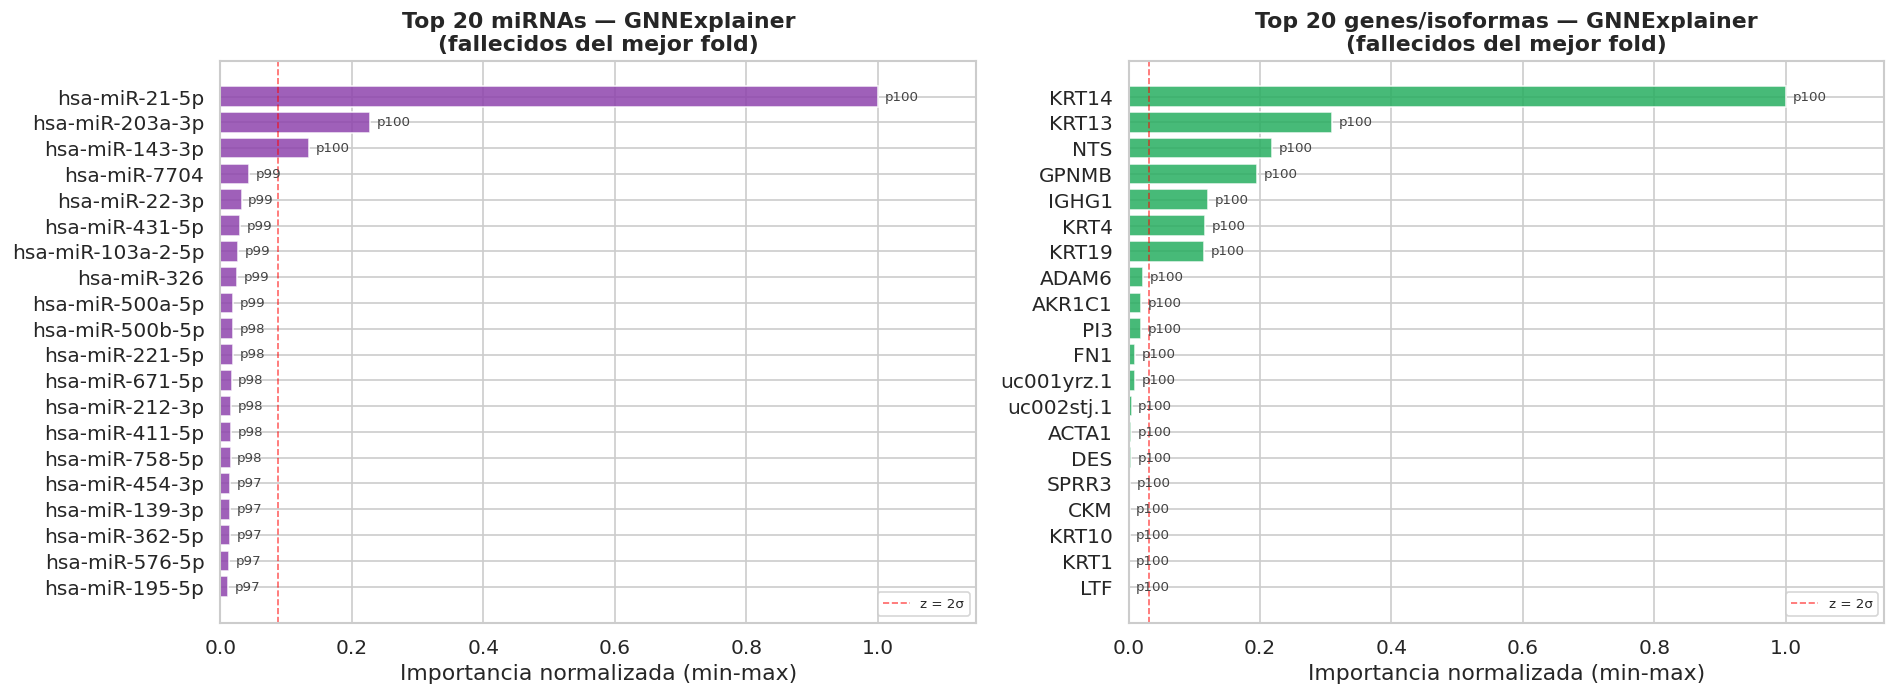

  miRNA más importante : hsa-miR-21-5p  (z=23.35, p100)
  Gen más importante   : KRT14  (z=65.82, p100)


In [ ]:
# ── Visualización GNNExplainer ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def barplot_importancia(ax, df, name_col, color, titulo, top_n=20):
    top = df.head(top_n).copy()
    top_r = top[::-1].reset_index(drop=True)   # invertir para barh

    bars = ax.barh(
        top_r[name_col], top_r['imp_minmax'],
        color=color, alpha=0.85, edgecolor='white'
    )
    # Anotación percentil en cada barra
    for i, (_, row) in enumerate(top_r.iterrows()):
        ax.text(
            row['imp_minmax'] + 0.01, i,
            f"p{row['imp_percentil']:.0f}",
            va='center', fontsize=8, color='#444'
        )
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Importancia normalizada (min-max)')
    ax.set_title(titulo, fontweight='bold')

    # Línea de z=2 como referencia
    if 'imp_zscore' in df.columns:
        z2_val = df['mean_importance'].mean() + 2 * df['mean_importance'].std()
        mn, mx = df['mean_importance'].min(), df['mean_importance'].max()
        z2_norm = (z2_val - mn) / (mx - mn + 1e-12)
        if 0 < z2_norm < 1:
            ax.axvline(z2_norm, color='red', lw=1, linestyle='--', alpha=0.6,
                       label='z = 2σ')
            ax.legend(fontsize=8)

barplot_importancia(
    axes[0], df_mirna_imp, 'mirna_name', '#8e44ad',
    'Top 20 miRNAs — GNNExplainer\n(fallecidos del mejor fold)'
)
barplot_importancia(
    axes[1], df_isoform_imp, 'gen', '#27ae60',
    'Top 20 genes/isoformas — GNNExplainer\n(fallecidos del mejor fold)'
)

plt.tight_layout()
plt.show()

# Diagnóstico rápido
top1_mirna = df_mirna_imp.iloc[0]
top1_iso   = df_isoform_imp.iloc[0]
print(f'  miRNA más importante : {top1_mirna["mirna_name"]}  '
      f'(z={top1_mirna["imp_zscore"]:.2f}, p{top1_mirna["imp_percentil"]:.0f})')
print(f'  Gen más importante   : {top1_iso["gen"]}  '
      f'(z={top1_iso["imp_zscore"]:.2f}, p{top1_iso["imp_percentil"]:.0f})')

Cálculo de importancias separadas por grupo (corta y larga)
sobre los pacientes del fold de validación.

In [ ]:
# ── GNNExplainer separado por grupo Corta vs Larga ───────────────────
print(f'Corta (≤{MEDIAN_THR:.0f}d): {len(q1_val)} pacientes')
print(f'Larga (>{MEDIAN_THR:.0f}d): {len(q4_val)} pacientes')

results_corta = run_gnnexplainer(best_model, graph_all, list(q1_val), hpv_tensor)
results_larga = run_gnnexplainer(best_model, graph_all, list(q4_val), hpv_tensor)

df_corta_mirna = results_corta['mirna_importance'].copy()
df_larga_mirna = results_larga['mirna_importance'].copy()
df_corta_mirna['mirna_name'] = df_corta_mirna['mirna_id'].map(mimat_to_name).fillna(df_corta_mirna['mirna_id'])
df_larga_mirna['mirna_name'] = df_larga_mirna['mirna_id'].map(mimat_to_name).fillna(df_larga_mirna['mirna_id'])

Corta (≤450d): 25 pacientes
Larga (>450d): 25 pacientes


Normalización de las importancias por grupo corta y larga (miRNAs).

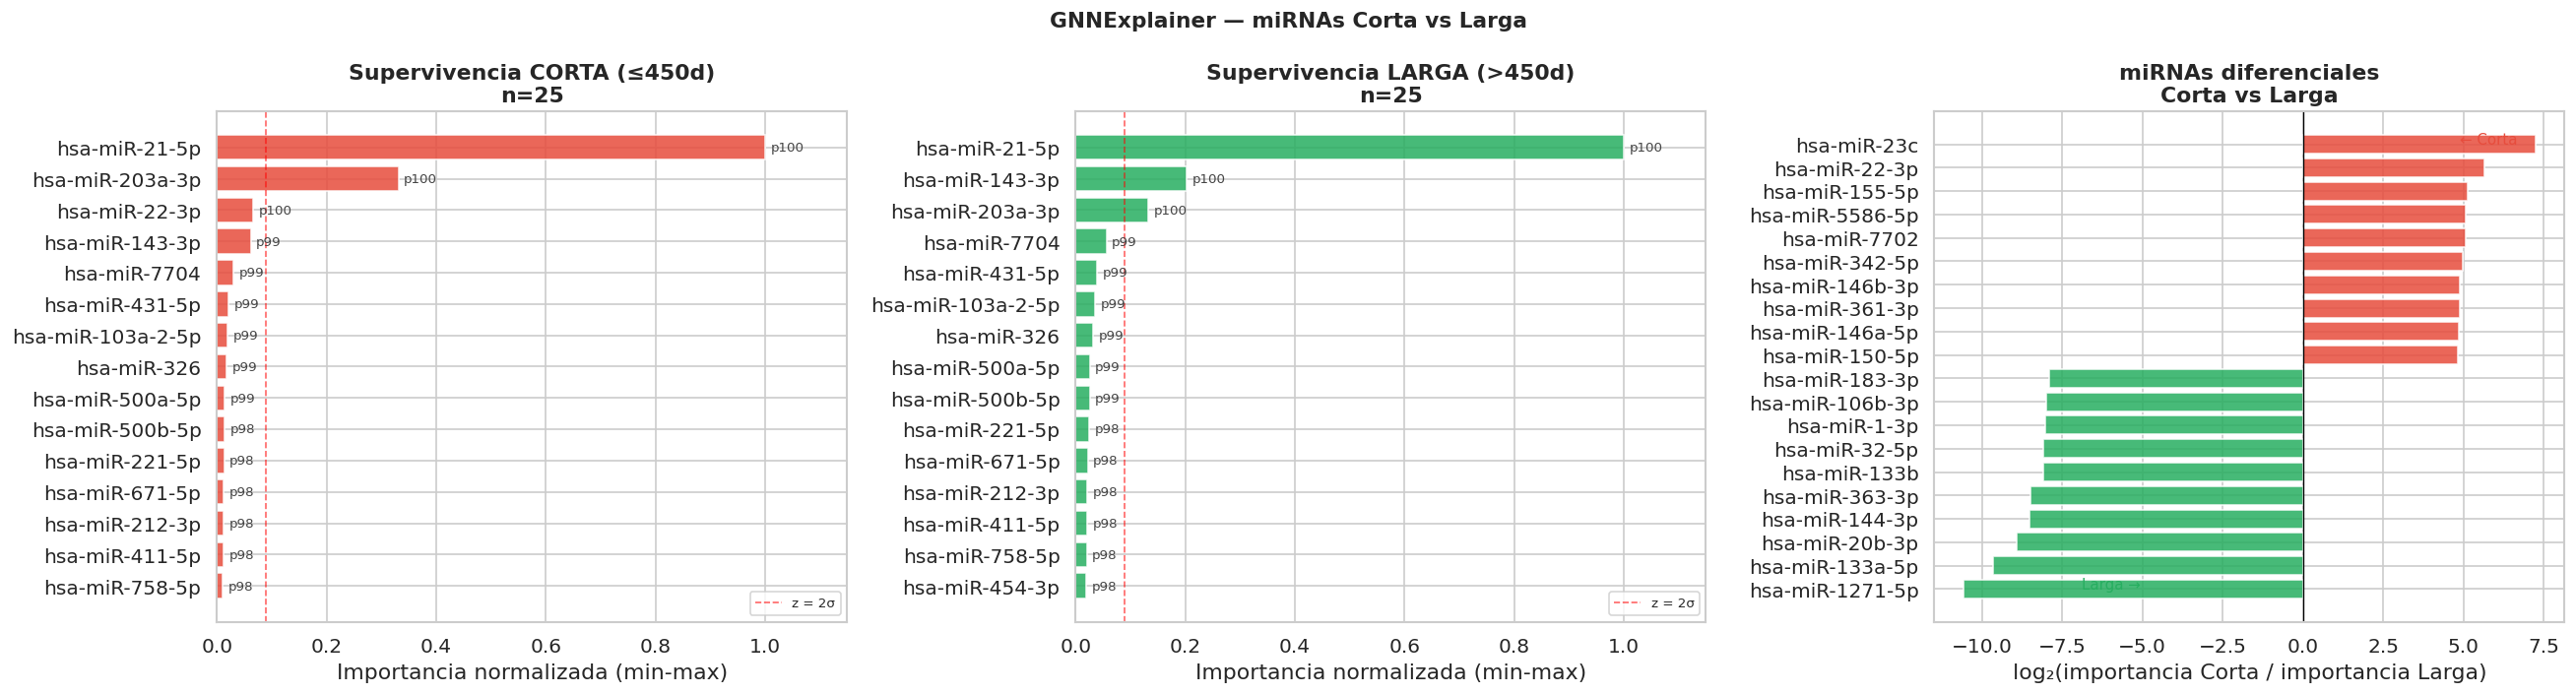

miRNAs más específicos de Supervivencia CORTA (modelo los usa más para predecir muerte temprana):
     mirna_name  imp_minmax_corta  imp_minmax_larga  log2_ratio
    hsa-miR-23c          0.000569          0.000003    7.262982
  hsa-miR-22-3p          0.065980          0.001298    5.666519
 hsa-miR-155-5p          0.001209          0.000033    5.147590
hsa-miR-5586-5p          0.000921          0.000027    5.059948
   hsa-miR-7702          0.001346          0.000039    5.058435

miRNAs más específicos de Supervivencia LARGA:
     mirna_name  imp_minmax_corta  imp_minmax_larga  log2_ratio
 hsa-miR-363-3p      1.032407e-06          0.000734   -8.498866
 hsa-miR-144-3p      4.366349e-08          0.000384   -8.527260
 hsa-miR-20b-3p      2.074358e-06          0.001475   -8.907080
hsa-miR-133a-5p      4.917197e-07          0.001195   -9.646585
hsa-miR-1271-5p      1.951285e-06          0.004541  -10.587746


In [ ]:
# ── Normalizar Corta y Larga ──────────────────────────────────────────
df_corta_mirna = normalizar_importancias(df_corta_mirna)
df_larga_mirna = normalizar_importancias(df_larga_mirna)

# ── Ratio diferencial Corta vs Larga ─────────────────────────────────
df_ratio = df_corta_mirna[['mirna_id','mirna_name','imp_minmax']].merge(
    df_larga_mirna[['mirna_id','imp_minmax']],
    on='mirna_id', suffixes=('_corta','_larga')
)
# log2 ratio: >0 = más importante en Corta, <0 = más importante en Larga
df_ratio['log2_ratio'] = np.log2(
    (df_ratio['imp_minmax_corta'] + 1e-6) / (df_ratio['imp_minmax_larga'] + 1e-6)
)
df_ratio = df_ratio.sort_values('log2_ratio', ascending=False)

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# [0] Top 15 Corta
barplot_importancia(
    axes[0], df_corta_mirna, 'mirna_name', '#e74c3c',
    f'Supervivencia CORTA (≤{MEDIAN_THR:.0f}d)\nn={len(q1_val)}',
    top_n=15
)

# [1] Top 15 Larga
barplot_importancia(
    axes[1], df_larga_mirna, 'mirna_name', '#27ae60',
    f'Supervivencia LARGA (>{MEDIAN_THR:.0f}d)\nn={len(q4_val)}',
    top_n=15
)

# [2] Log2 ratio — miRNAs más diferenciales entre grupos
ax = axes[2]
TOP_RATIO = 20   # top 10 de cada extremo
df_plot = pd.concat([
    df_ratio.head(10),           # más específicos de Corta
    df_ratio.tail(10)            # más específicos de Larga
]).drop_duplicates('mirna_id').sort_values('log2_ratio')

colors_ratio = ['#27ae60' if v < 0 else '#e74c3c' for v in df_plot['log2_ratio']]
ax.barh(df_plot['mirna_name'], df_plot['log2_ratio'],
        color=colors_ratio, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('log₂(importancia Corta / importancia Larga)')
ax.set_title('miRNAs diferenciales\nCorta vs Larga', fontweight='bold')
# Etiqueta de grupo
ax.text(ax.get_xlim()[1]*0.6,  len(df_plot)-1, '← Corta',  color='#e74c3c', fontsize=9)
ax.text(ax.get_xlim()[0]*0.6,  0,              'Larga →',  color='#27ae60', fontsize=9)

plt.suptitle('GNNExplainer — miRNAs Corta vs Larga', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Conclusiones ──────────────────────────────────────────
print('miRNAs más específicos de Supervivencia CORTA (modelo los usa más para predecir muerte temprana):')
print(df_ratio.head(5)[['mirna_name','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))
print()
print('miRNAs más específicos de Supervivencia LARGA:')
print(df_ratio.tail(5)[['mirna_name','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))

Normalización de las importancias por grupo corta y larga (isoformas).

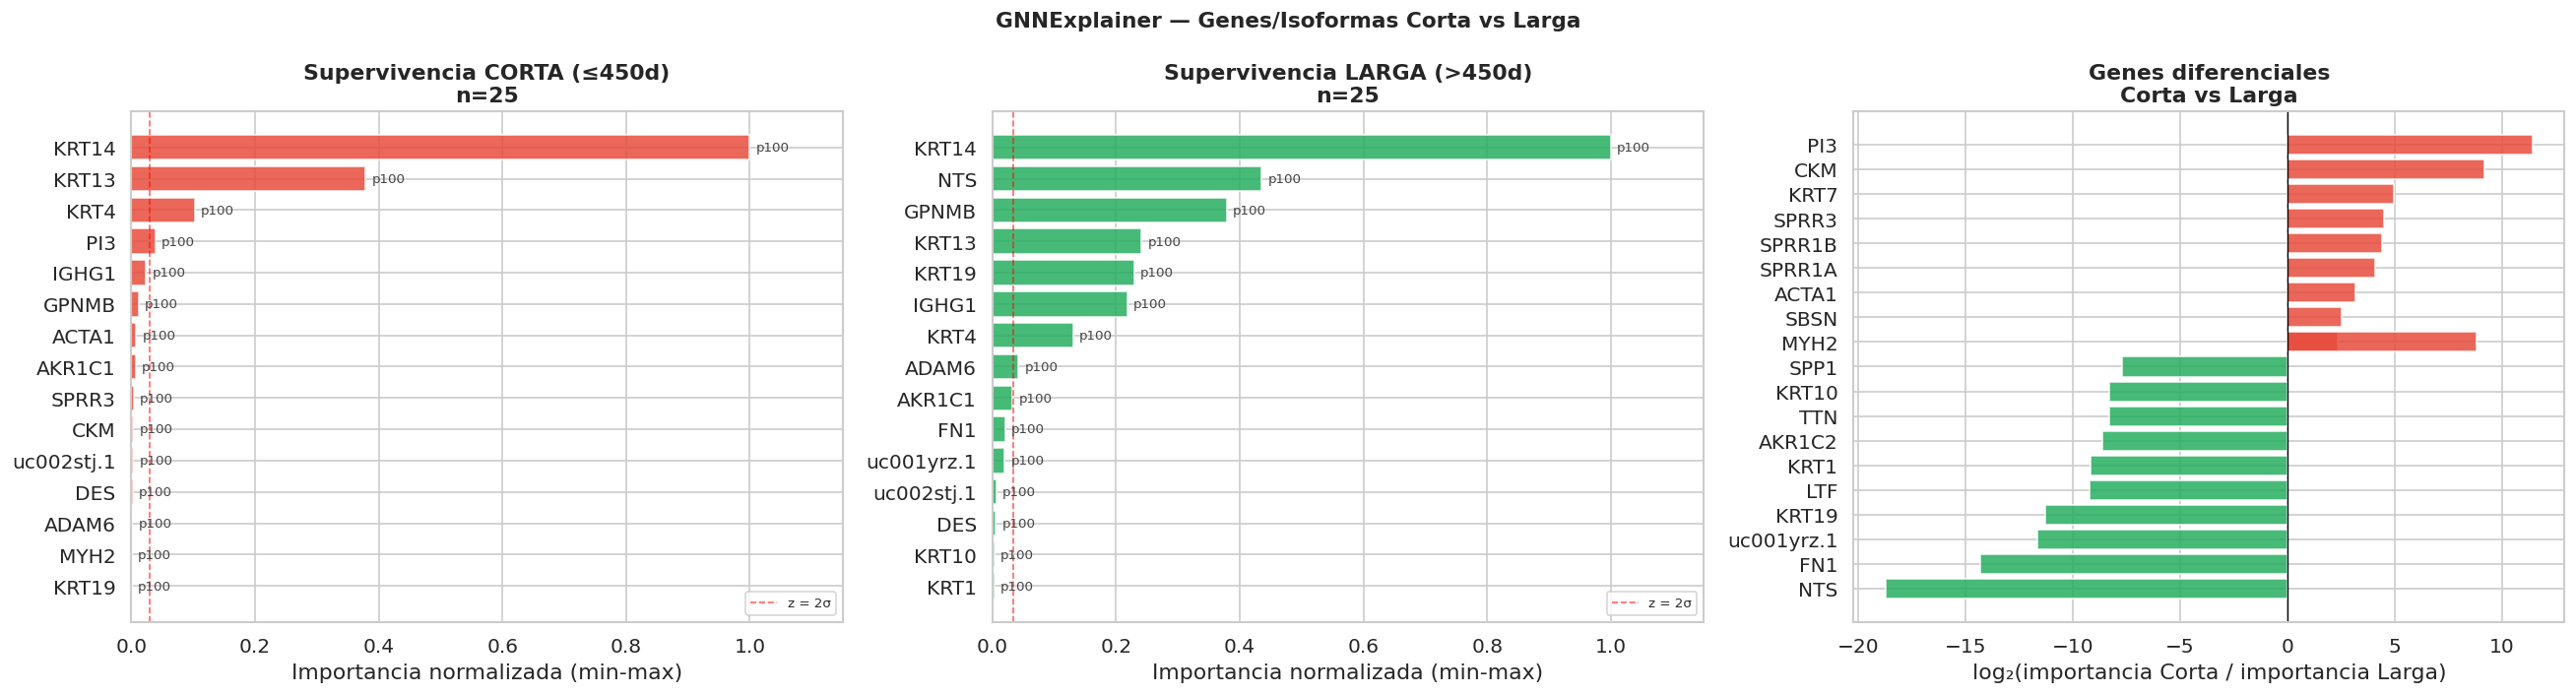

Genes más específicos de Supervivencia CORTA:
  gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
  PI3          0.038651      1.313190e-05   11.417361
  CKM          0.003225      4.499210e-06    9.196342
 MYH2          0.000475      6.558695e-08    8.803665
 KRT7          0.000030      8.207260e-10    4.963217
SPRR3          0.003724      1.642766e-04    4.494357

Genes más específicos de Supervivencia LARGA:
       gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
       LTF      3.106063e-08          0.000622   -9.238431
     KRT19      8.979980e-05          0.228729  -11.298670
uc001yrz.1      5.261043e-06          0.020064  -11.645967
       FN1      7.358583e-10          0.020614  -14.330373
       NTS      3.012519e-09          0.435664  -18.728519


In [ ]:
# ── Normalizar isoformas Corta y Larga ───────────────────────────────
df_corta_iso = results_corta['isoform_importance'].copy()
df_larga_iso = results_larga['isoform_importance'].copy()
df_corta_iso['gen'] = df_corta_iso['isoform_id'].map(isoform_to_gene).fillna(df_corta_iso['isoform_id'])
df_larga_iso['gen'] = df_larga_iso['isoform_id'].map(isoform_to_gene).fillna(df_larga_iso['isoform_id'])
df_corta_iso = normalizar_importancias(df_corta_iso)
df_larga_iso = normalizar_importancias(df_larga_iso)

# ── Ratio diferencial genes Corta vs Larga ───────────────────────────
df_ratio_iso = df_corta_iso[['isoform_id','gen','imp_minmax']].merge(
    df_larga_iso[['isoform_id','imp_minmax']],
    on='isoform_id', suffixes=('_corta','_larga')
)
df_ratio_iso['log2_ratio'] = np.log2(
    (df_ratio_iso['imp_minmax_corta'] + 1e-6) / (df_ratio_iso['imp_minmax_larga'] + 1e-6)
)
df_ratio_iso = df_ratio_iso.sort_values('log2_ratio', ascending=False)

# ── Visualización genes ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

barplot_importancia(
    axes[0], df_corta_iso, 'gen', '#e74c3c',
    f'Supervivencia CORTA (≤{MEDIAN_THR:.0f}d)\nn={len(q1_val)}',
    top_n=15
)
barplot_importancia(
    axes[1], df_larga_iso, 'gen', '#27ae60',
    f'Supervivencia LARGA (>{MEDIAN_THR:.0f}d)\nn={len(q4_val)}',
    top_n=15
)

# [2] Log2 ratio genes
ax = axes[2]
df_plot_iso = pd.concat([
    df_ratio_iso.head(10),
    df_ratio_iso.tail(10)
]).drop_duplicates('isoform_id').sort_values('log2_ratio')

colors_iso = ['#27ae60' if v < 0 else '#e74c3c' for v in df_plot_iso['log2_ratio']]
ax.barh(df_plot_iso['gen'], df_plot_iso['log2_ratio'],
        color=colors_iso, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('log₂(importancia Corta / importancia Larga)')
ax.set_title('Genes diferenciales\nCorta vs Larga', fontweight='bold')
xlim = ax.get_xlim()


plt.suptitle('GNNExplainer — Genes/Isoformas Corta vs Larga', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Conclusiones genes ────────────────────────────────────────────────
print('Genes más específicos de Supervivencia CORTA:')
print(df_ratio_iso.head(5)[['gen','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))
print()
print('Genes más específicos de Supervivencia LARGA:')
print(df_ratio_iso.tail(5)[['gen','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))

Filtrado de isoformas genuinamente diferenciales (|log₂-ratio| > 1)
entre supervivencia corta y larga.

In [ ]:
# Filtrar solo los realmente diferenciales (|log2_ratio| > 1 = al menos 2x diferencia)
df_plot_iso = pd.concat([
    df_ratio_iso[df_ratio_iso['log2_ratio'] >  1].head(10),   # Corta clara
    df_ratio_iso[df_ratio_iso['log2_ratio'] < -1].tail(10)    # Larga clara
]).drop_duplicates('isoform_id').sort_values('log2_ratio')

Consulta de isoformas específicas de interés biológico (p.ej. H19).

In [ ]:
print(df_ratio_iso[df_ratio_iso['gen'] == 'H19'][['isoform_id','gen','imp_minmax_corta','imp_minmax_larga','log2_ratio']])

     isoform_id  gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
32   uc001lva.3  H19      1.241470e-06      1.392446e-07    0.976367
152  uc001luz.1  H19      1.859154e-11      1.263893e-10   -0.000156
91   uc001lvb.1  H19      1.755721e-09      1.163734e-07   -0.156289
53   uc001lve.2  H19      3.860762e-08      2.103688e-07   -0.220796


Agregación de importancias por gen (media sobre isoformas del mismo gen).

In [ ]:
# ── Agregar por gen (media sobre isoformas) ───────────────────────────
df_corta_gen = (df_corta_iso.groupby('gen')['mean_importance']
                .mean().reset_index())
df_larga_gen = (df_larga_iso.groupby('gen')['mean_importance']
                .mean().reset_index())
df_corta_gen = normalizar_importancias(df_corta_gen)
df_larga_gen = normalizar_importancias(df_larga_gen)

df_ratio_gen = df_corta_gen[['gen','imp_minmax']].merge(
    df_larga_gen[['gen','imp_minmax']],
    on='gen', suffixes=('_corta','_larga')
)
df_ratio_gen['log2_ratio'] = np.log2(
    (df_ratio_gen['imp_minmax_corta'] + 1e-6) / (df_ratio_gen['imp_minmax_larga'] + 1e-6)
)
df_ratio_gen = df_ratio_gen.sort_values('log2_ratio', ascending=False)

# H19 agregado
print('H19 agregado:')
print(df_ratio_gen[df_ratio_gen['gen']=='H19'])

H19 agregado:
      gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
1270  H19      6.409257e-07      2.330566e-07    0.412271


Visualización del log₂-ratio diferencial por gen entre corta y larga.

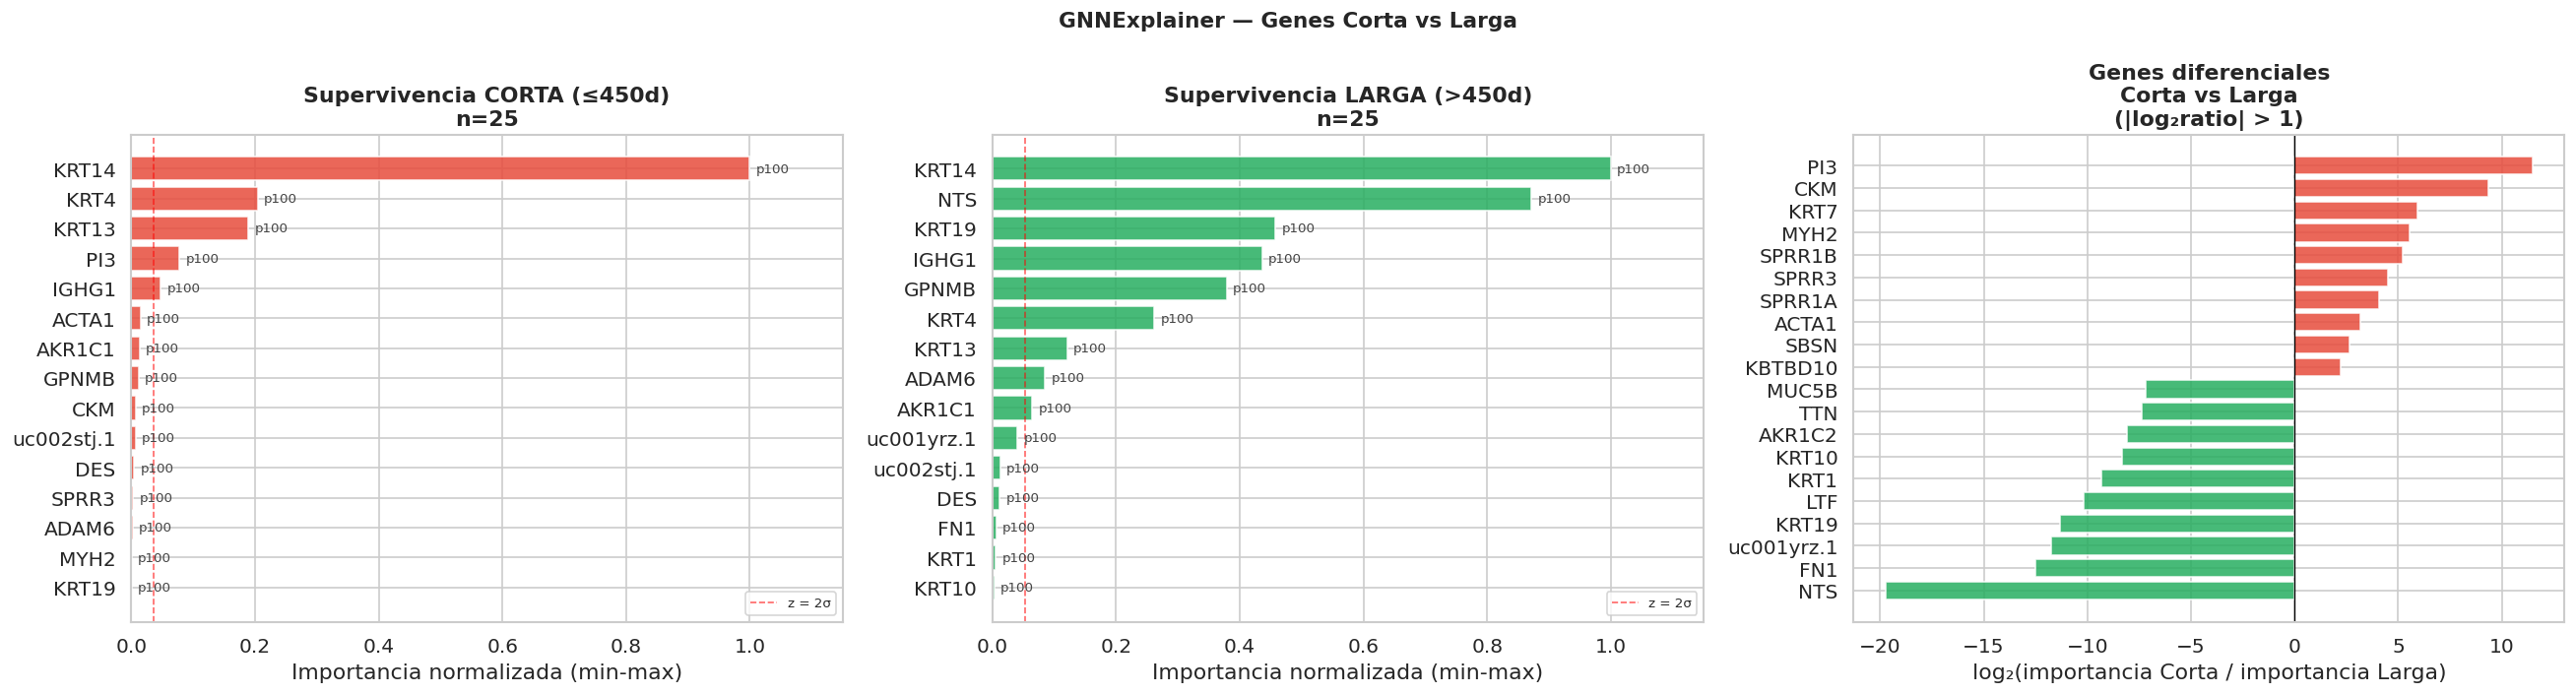

Detalle isoformas H19:
isoform_id gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
uc001lva.3 H19      1.241470e-06      1.392446e-07    0.976367
uc001lve.2 H19      3.860762e-08      2.103688e-07   -0.220796
uc001lvb.1 H19      1.755721e-09      1.163734e-07   -0.156289
uc001luz.1 H19      1.859154e-11      1.263893e-10   -0.000156

Genes más específicos de Supervivencia CORTA:
   gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
   PI3          0.077301      2.626380e-05   11.469312
   CKM          0.006450      8.998419e-06    9.333643
  KRT7          0.000060      1.641452e-09    5.938742
  MYH2          0.000531      1.022644e-05    5.565244
SPRR1B          0.000044      2.021122e-07    5.233590

Genes más específicos de Supervivencia LARGA:
       gen  imp_minmax_corta  imp_minmax_larga  log2_ratio
       LTF      6.212125e-08          0.001244  -10.194453
     KRT19      1.795996e-04          0.457458  -11.306633
uc001yrz.1      1.052209e-05          0.040127  -11.766004
  

In [ ]:
# ── Normalizar isoformas Corta y Larga ───────────────────────────────
df_corta_iso = results_corta['isoform_importance'].copy()
df_larga_iso = results_larga['isoform_importance'].copy()
df_corta_iso['gen'] = df_corta_iso['isoform_id'].map(isoform_to_gene).fillna(df_corta_iso['isoform_id'])
df_larga_iso['gen'] = df_larga_iso['isoform_id'].map(isoform_to_gene).fillna(df_larga_iso['isoform_id'])
df_corta_iso = normalizar_importancias(df_corta_iso)
df_larga_iso = normalizar_importancias(df_larga_iso)

# ── Agregar por gen + reordenar ───────────────────────────────────────
df_corta_gen = (df_corta_iso.groupby('gen')['mean_importance']
                .mean().reset_index()
                .pipe(normalizar_importancias)
                .sort_values('mean_importance', ascending=False)
                .reset_index(drop=True))

df_larga_gen = (df_larga_iso.groupby('gen')['mean_importance']
                .mean().reset_index()
                .pipe(normalizar_importancias)
                .sort_values('mean_importance', ascending=False)
                .reset_index(drop=True))

# ── Ratio diferencial genes Corta vs Larga ───────────────────────────
df_ratio_gen = df_corta_gen[['gen','imp_minmax']].merge(
    df_larga_gen[['gen','imp_minmax']],
    on='gen', suffixes=('_corta','_larga')
)
df_ratio_gen['log2_ratio'] = np.log2(
    (df_ratio_gen['imp_minmax_corta'] + 1e-6) / (df_ratio_gen['imp_minmax_larga'] + 1e-6)
)
df_ratio_gen = df_ratio_gen.sort_values('log2_ratio', ascending=False)

# También necesario para la nota H19 al final
df_ratio_iso = df_corta_iso[['isoform_id','gen','imp_minmax']].merge(
    df_larga_iso[['isoform_id','imp_minmax']],
    on='isoform_id', suffixes=('_corta','_larga')
)
df_ratio_iso['log2_ratio'] = np.log2(
    (df_ratio_iso['imp_minmax_corta'] + 1e-6) / (df_ratio_iso['imp_minmax_larga'] + 1e-6)
)

# ── Visualización genes ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

barplot_importancia(
    axes[0], df_corta_gen, 'gen', '#e74c3c',
    f'Supervivencia CORTA (≤{MEDIAN_THR:.0f}d)\nn={len(q1_val)}',
    top_n=15
)
barplot_importancia(
    axes[1], df_larga_gen, 'gen', '#27ae60',
    f'Supervivencia LARGA (>{MEDIAN_THR:.0f}d)\nn={len(q4_val)}',
    top_n=15
)

# [2] Log2 ratio — solo genes realmente diferenciales (|log2_ratio| > 1)
ax = axes[2]
df_plot_gen = pd.concat([
    df_ratio_gen[df_ratio_gen['log2_ratio'] >  1].head(10),
    df_ratio_gen[df_ratio_gen['log2_ratio'] < -1].tail(10)
]).drop_duplicates('gen').sort_values('log2_ratio')

colors_gen = ['#27ae60' if v < 0 else '#e74c3c' for v in df_plot_gen['log2_ratio']]
ax.barh(df_plot_gen['gen'], df_plot_gen['log2_ratio'],
        color=colors_gen, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('log₂(importancia Corta / importancia Larga)')
ax.set_title('Genes diferenciales\nCorta vs Larga\n(|log₂ratio| > 1)', fontweight='bold')
xlim = ax.get_xlim()

plt.suptitle('GNNExplainer — Genes Corta vs Larga', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Nota H19 ─────────────────────────────────────────────────────────
print('Detalle isoformas H19:')
print(df_ratio_iso[df_ratio_iso['gen'] == 'H19'][
    ['isoform_id','gen','imp_minmax_corta','imp_minmax_larga','log2_ratio']
].to_string(index=False))
print()

# ── Conclusiones genes ────────────────────────────────────────────────
print('Genes más específicos de Supervivencia CORTA:')
print(df_ratio_gen.head(5)[['gen','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))
print()
print('Genes más específicos de Supervivencia LARGA:')
print(df_ratio_gen.tail(5)[['gen','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))

## 4b. GNNExplainer: relaciones miRNA↔miRNA y miRNA→isoforma más importantes

Ranking de pares de miRNAs co-expresados e interacciones miRNA→isoforma
por peso de atención agregado sobre las tres capas del modelo.
Análisis diferencial corta vs larga mediante log₂-ratio de importancia por arista.
Cruce con nombres biológicos (miRBase, diccionario UCSC→gen) para interpretación.

Ranking de pares miRNA↔miRNA por peso de atención agregado.

In [ ]:
#── Top relaciones miRNA↔miRNA ───────────────────────────────
df_edge_mm = explainer_results['edge_mm_importance'].copy()
df_edge_mm['src_name'] = df_edge_mm['mirna_src'].map(mimat_to_name).fillna(df_edge_mm['mirna_src'])
df_edge_mm['dst_name'] = df_edge_mm['mirna_dst'].map(mimat_to_name).fillna(df_edge_mm['mirna_dst'])

df_edge_mm['pair'] = df_edge_mm.apply(
    lambda r: tuple(sorted([r['src_name'], r['dst_name']])), axis=1
)
df_pairs_mm = (
    df_edge_mm.groupby('pair')['mean_importance']
    .mean().reset_index()
    .sort_values('mean_importance', ascending=False)
    .reset_index(drop=True)
)
df_pairs_mm[['mirna_A','mirna_B']] = pd.DataFrame(df_pairs_mm['pair'].tolist(), index=df_pairs_mm.index)
df_pairs_mm = df_pairs_mm.drop(columns='pair')
df_pairs_mm = normalizar_importancias(df_pairs_mm)

print('Top 20 pares miRNA↔miRNA (GNNExplainer):')
print(df_pairs_mm[['mirna_A','mirna_B','imp_minmax','imp_zscore','imp_percentil']].head(20).to_string(index=False))

Top 20 pares miRNA↔miRNA (GNNExplainer):
          mirna_A         mirna_B  imp_minmax  imp_zscore  imp_percentil
   hsa-miR-143-3p    hsa-miR-7704    1.000000    9.709730     100.000000
   hsa-miR-143-3p  hsa-miR-431-5p    0.924694    8.955079      99.960175
hsa-miR-103a-2-5p  hsa-miR-143-3p    0.908529    8.793079      99.920350
   hsa-miR-143-3p     hsa-miR-326    0.895569    8.663206      99.880526
   hsa-miR-143-3p hsa-miR-500a-5p    0.865525    8.362129      99.840701
   hsa-miR-143-3p hsa-miR-500b-5p    0.865458    8.361459      99.800876
   hsa-miR-143-3p  hsa-miR-221-5p    0.860663    8.313411      99.761051
   hsa-miR-143-3p  hsa-miR-671-5p    0.850003    8.206583      99.721227
   hsa-miR-143-3p  hsa-miR-212-3p    0.848094    8.187454      99.681402
   hsa-miR-143-3p  hsa-miR-411-5p    0.847367    8.180161      99.641577
   hsa-miR-143-3p  hsa-miR-758-5p    0.842353    8.129914      99.601752
   hsa-miR-143-3p  hsa-miR-454-3p    0.839966    8.105996      99.561928
   hsa-miR

Ranking de interacciones miRNA→gen por peso de atención agregado.

In [ ]:
#  ── Top relaciones miRNA→gen ─────────────────────────────────
df_edge_mi = explainer_results['edge_mi_importance'].copy()
df_edge_mi['mirna_name'] = df_edge_mi['mirna_id'].map(mimat_to_name).fillna(df_edge_mi['mirna_id'])
df_edge_mi['gen']        = df_edge_mi['isoform_id'].map(isoform_to_gene).fillna(df_edge_mi['isoform_id'])

df_edge_mi_gen = (
    df_edge_mi.groupby(['mirna_name','gen'])['mean_importance']
    .mean().reset_index()
    .sort_values('mean_importance', ascending=False)
    .reset_index(drop=True)
)
df_edge_mi_gen = normalizar_importancias(df_edge_mi_gen)

print('Top 20 relaciones miRNA→gen (GNNExplainer):')
print(df_edge_mi_gen[['mirna_name','gen','imp_minmax','imp_zscore','imp_percentil']].head(20).to_string(index=False))

Top 20 relaciones miRNA→gen (GNNExplainer):
   mirna_name      gen  imp_minmax  imp_zscore  imp_percentil
hsa-miR-21-5p     YAP1    1.000000   18.801391     100.000000
hsa-miR-21-5p     SOX2    0.999846   18.798477      99.997357
hsa-miR-21-5p    STAT3    0.999845   18.798474      99.994715
hsa-miR-21-5p    DCAF7    0.999845   18.798474      99.992072
hsa-miR-21-5p    ACBD5    0.999845   18.798474      99.858615
hsa-miR-21-5p   ACVR1C    0.999845   18.798474      99.858615
hsa-miR-21-5p   RNF111    0.999845   18.798474      99.858615
hsa-miR-21-5p     AAK1    0.999845   18.798474      99.858615
hsa-miR-21-5p   KCNK10    0.999845   18.798474      99.858615
hsa-miR-21-5p KIAA1468    0.999845   18.798474      99.858615
hsa-miR-21-5p     FGD4    0.999845   18.798474      99.858615
hsa-miR-21-5p   FBXO28    0.999845   18.798474      99.858615
hsa-miR-21-5p      FTO    0.999845   18.798474      99.858615
hsa-miR-21-5p     FRS2    0.999845   18.798474      99.858615
hsa-miR-21-5p    FOXP1    

Visualización de la red integrada miRNA↔miRNA y miRNA→gen.

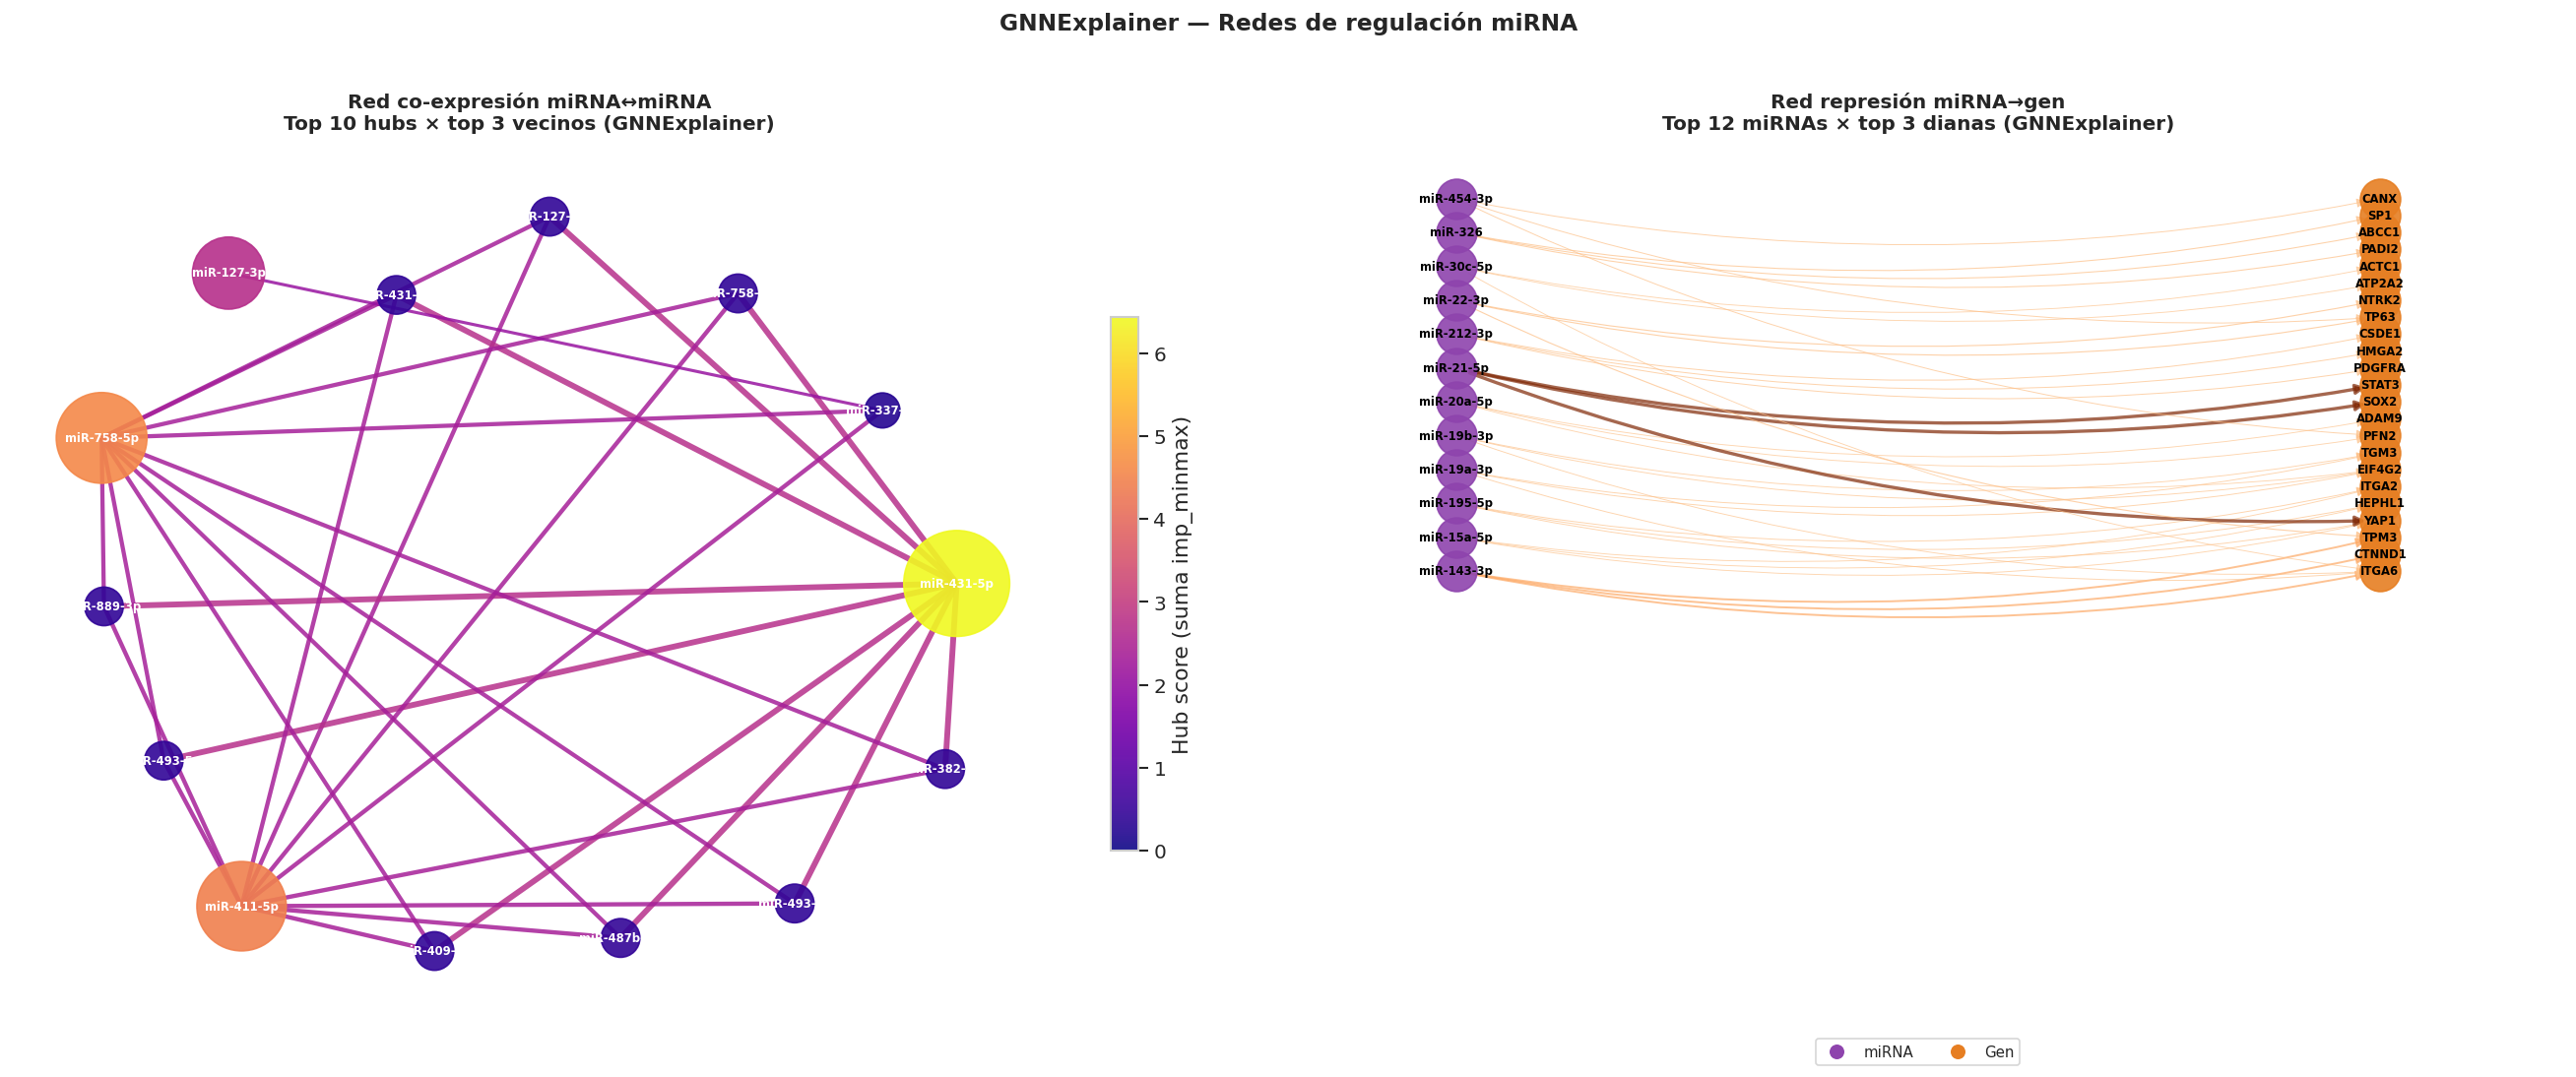

In [ ]:
# ── Visualización red integrada miRNA↔miRNA + miRNA→gen ───────────────
import networkx as nx
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# ── [0] Red miRNA↔miRNA — distribuida por hubs ───────────────────────
ax = axes[0]
TOP_POR_MIRNA_MM = 3
TOP_MIRNAS_MM    = 10

top_hubs = (pd.concat([df_pairs_mm['mirna_A'], df_pairs_mm['mirna_B']])
              .value_counts().head(TOP_MIRNAS_MM).index.tolist())

df_top_mm = (df_pairs_mm[
                df_pairs_mm['mirna_A'].isin(top_hubs) |
                df_pairs_mm['mirna_B'].isin(top_hubs)
             ]
             .assign(hub=lambda x: x.apply(
                 lambda r: r['mirna_A'] if r['mirna_A'] in top_hubs else r['mirna_B'], axis=1
             ))
             .groupby('hub', group_keys=False)
             .apply(lambda x: x.nlargest(TOP_POR_MIRNA_MM, 'imp_minmax'))
             .drop_duplicates(subset=['mirna_A','mirna_B'])
             .reset_index(drop=True))

G_mm = nx.Graph()
for _, row in df_top_mm.iterrows():
    G_mm.add_edge(row['mirna_A'], row['mirna_B'], weight=row['imp_minmax'])

pos         = nx.spring_layout(G_mm, seed=42, k=2.0)
weights     = [G_mm[u][v]['weight'] for u,v in G_mm.edges()]
widths      = [1.5 + w * 12 for w in weights]
node_imp    = {n: df_pairs_mm[(df_pairs_mm['mirna_A']==n)|(df_pairs_mm['mirna_B']==n)]['imp_minmax'].sum()
               for n in G_mm.nodes()}
node_sizes  = [node_imp.get(n,0) * 600 + 300 for n in G_mm.nodes()]
node_colors = [node_imp.get(n,0) for n in G_mm.nodes()]
edge_cmap   = plt.cm.plasma
edge_colors = [edge_cmap(0.3 + w * 0.7) for w in weights]

nx.draw_networkx_edges(G_mm, pos, ax=ax, width=widths,
                       edge_color=edge_colors, alpha=0.85)
nc = nx.draw_networkx_nodes(G_mm, pos, ax=ax,
                             node_size=node_sizes,
                             node_color=node_colors,
                             cmap=plt.cm.plasma, alpha=0.9,
                             vmin=0, vmax=max(node_colors))
labels_short = {n: n.replace('hsa-', '') for n in G_mm.nodes()}
nx.draw_networkx_labels(G_mm, pos, labels=labels_short, ax=ax,
                        font_size=7, font_color='white', font_weight='bold')
plt.colorbar(nc, ax=ax, label='Hub score (suma imp_minmax)', shrink=0.6)
ax.set_title(f'Red co-expresión miRNA↔miRNA\nTop {TOP_MIRNAS_MM} hubs × top {TOP_POR_MIRNA_MM} vecinos (GNNExplainer)',
             fontweight='bold', fontsize=12)
ax.axis('off')

# ── [1] Red bipartita miRNA→gen ───────────────────────────────────────
ax = axes[1]
TOP_POR_MIRNA = 3
TOP_MIRNAS    = 12

top_mirnas_list = (df_edge_mi_gen.groupby('mirna_name')['imp_minmax']
                   .sum().nlargest(TOP_MIRNAS).index.tolist())
df_top_mi = (df_edge_mi_gen[df_edge_mi_gen['mirna_name'].isin(top_mirnas_list)]
             .groupby('mirna_name', group_keys=False)
             .apply(lambda x: x.nlargest(TOP_POR_MIRNA, 'imp_minmax'))
             .reset_index(drop=True))

G_mi        = nx.DiGraph()
mirna_nodes = df_top_mi['mirna_name'].unique().tolist()
gen_nodes   = df_top_mi['gen'].unique().tolist()

for _, row in df_top_mi.iterrows():
    G_mi.add_edge(row['mirna_name'], row['gen'], weight=row['imp_minmax'])

pos_bi = {}
for i, m in enumerate(mirna_nodes):
    pos_bi[m] = (-1, i / max(len(mirna_nodes)-1, 1))
for i, g in enumerate(gen_nodes):
    pos_bi[g] = (1,  i / max(len(gen_nodes)-1,   1))

edge_weights_mi = [G_mi[u][v]['weight'] for u,v in G_mi.edges()]
widths_mi       = [0.5 + min(w, 0.3) * 5 for w in edge_weights_mi]
edge_colors_mi  = [plt.cm.Oranges(0.3 + w * 0.7) for w in edge_weights_mi]

nx.draw_networkx_nodes(G_mi, pos_bi, ax=ax, nodelist=mirna_nodes,
                       node_color='#8e44ad', node_size=600, alpha=0.9)
nx.draw_networkx_nodes(G_mi, pos_bi, ax=ax, nodelist=gen_nodes,
                       node_color='#e67e22', node_size=600, alpha=0.9)
nx.draw_networkx_edges(G_mi, pos_bi, ax=ax,
                       width=widths_mi, edge_color=edge_colors_mi,
                       arrows=True, arrowsize=12,
                       connectionstyle='arc3,rad=0.1', alpha=0.7)

# Etiquetas miRNA en negro (fondo blanco)
labels_mirna_short = {n: n.replace('hsa-', '') for n in mirna_nodes}
nx.draw_networkx_labels(G_mi, pos_bi, labels=labels_mirna_short, ax=ax,
                        font_size=7, font_color='black', font_weight='bold')
# Etiquetas gen en negro (fondo blanco)
nx.draw_networkx_labels(G_mi, pos_bi,
                        labels={n: n for n in gen_nodes}, ax=ax,
                        font_size=7, font_color='black', font_weight='bold')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#8e44ad',
           markersize=10, label='miRNA'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e67e22',
           markersize=10, label='Gen'),
]
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=9)
ax.set_title(f'Red represión miRNA→gen\nTop {TOP_MIRNAS} miRNAs × top {TOP_POR_MIRNA} dianas (GNNExplainer)',
             fontweight='bold', fontsize=12)
ax.set_xlim(-1.4, 1.4)
ax.axis('off')

plt.suptitle('GNNExplainer — Redes de regulación miRNA',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Análisis diferencial de pares miRNA↔miRNA entre corta y larga.

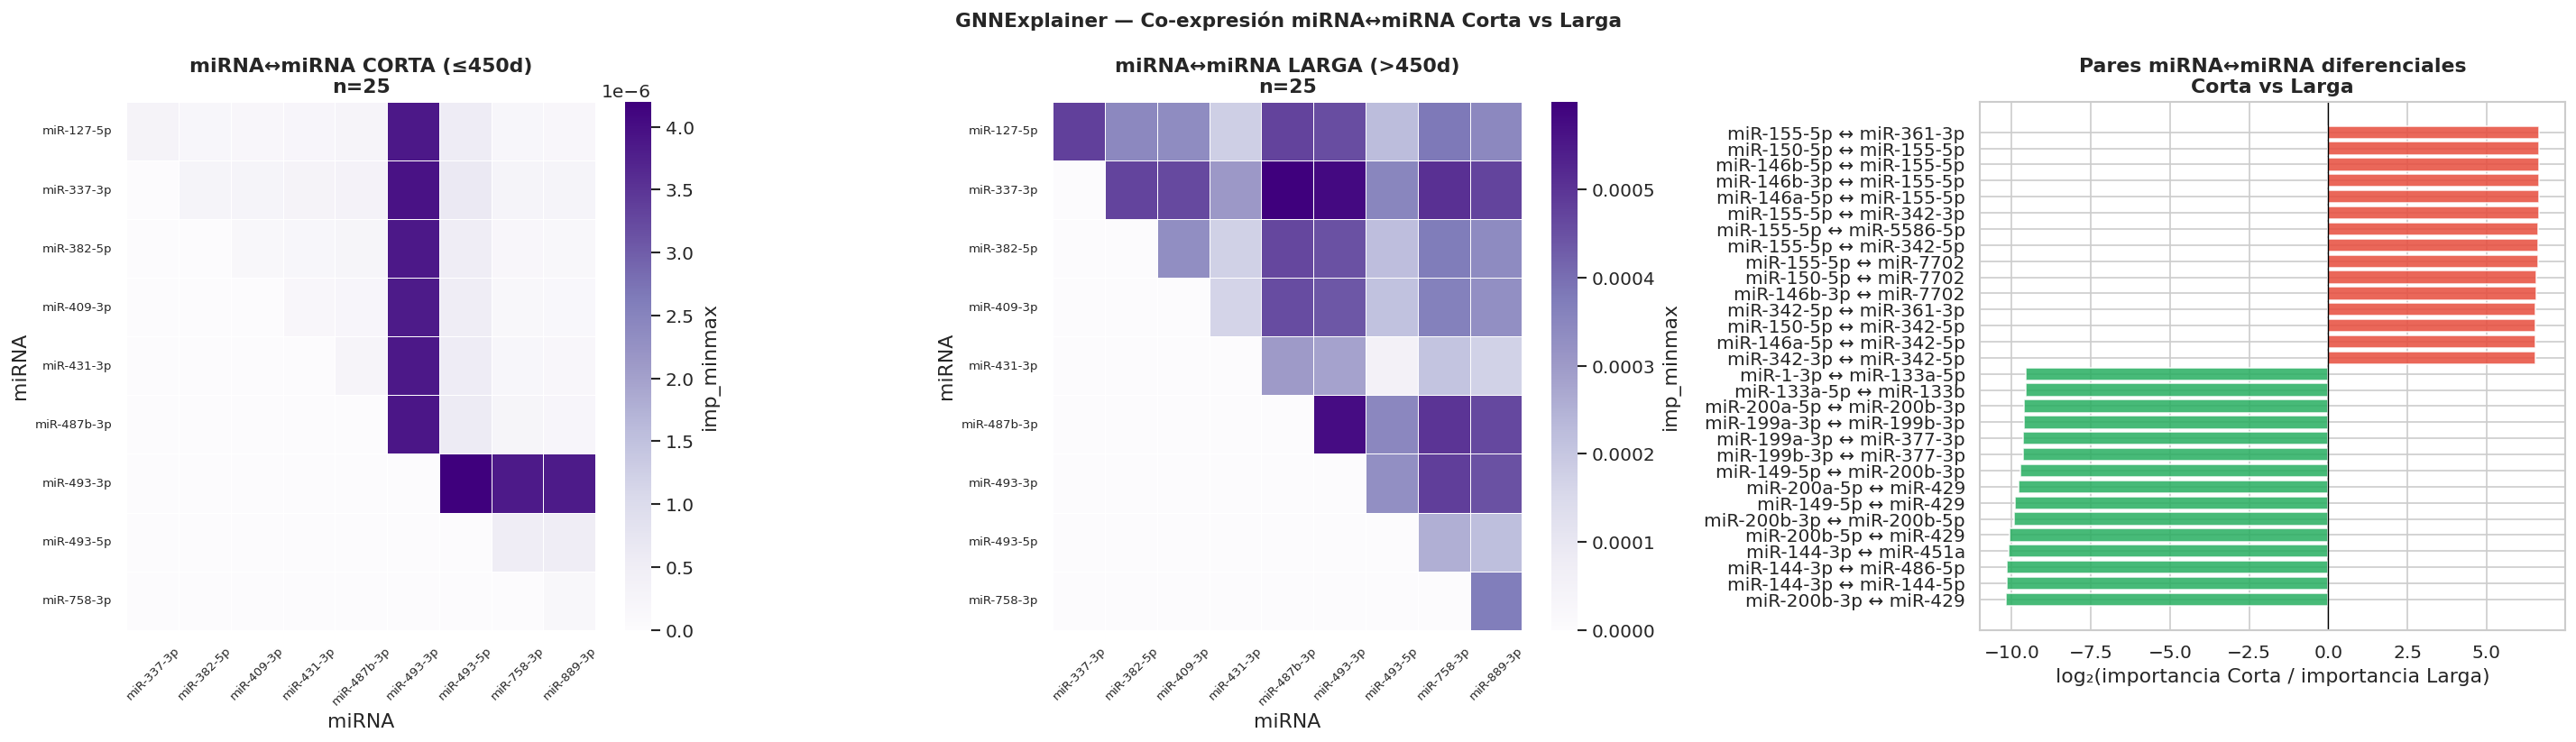

Pares más específicos de Supervivencia CORTA:
                             par  imp_minmax_corta  imp_minmax_larga  log2_ratio
 hsa-miR-155-5p ↔ hsa-miR-361-3p          0.015351          0.000152    6.651897
 hsa-miR-150-5p ↔ hsa-miR-155-5p          0.015002          0.000148    6.651387
hsa-miR-146b-5p ↔ hsa-miR-155-5p          0.014855          0.000147    6.649728
hsa-miR-146b-3p ↔ hsa-miR-155-5p          0.015692          0.000156    6.646759
hsa-miR-146a-5p ↔ hsa-miR-155-5p          0.015396          0.000153    6.646358

Pares más específicos de Supervivencia LARGA:
                            par  imp_minmax_corta  imp_minmax_larga  log2_ratio
  hsa-miR-200b-5p ↔ hsa-miR-429      1.904164e-07          0.001278  -10.069104
  hsa-miR-144-3p ↔ hsa-miR-451a      6.388310e-07          0.001800  -10.102100
hsa-miR-144-3p ↔ hsa-miR-486-5p      6.487915e-07          0.001877  -10.153413
hsa-miR-144-3p ↔ hsa-miR-144-5p      6.630303e-07          0.001908  -10.164595
  hsa-miR-200b-3p ↔ h

In [ ]:
# ── Ratio diferencial miRNA↔miRNA Corta vs Larga ──────────────────────
def edge_mm_to_pairs(results):
    df = results['edge_mm_importance'].copy()
    df['src_name'] = df['mirna_src'].map(mimat_to_name).fillna(df['mirna_src'])
    df['dst_name'] = df['mirna_dst'].map(mimat_to_name).fillna(df['mirna_dst'])
    df['pair'] = df.apply(
        lambda r: tuple(sorted([r['src_name'], r['dst_name']])), axis=1
    )
    df = (df.groupby('pair')['mean_importance']
            .mean().reset_index()
            .sort_values('mean_importance', ascending=False)
            .reset_index(drop=True))
    df[['mirna_A','mirna_B']] = pd.DataFrame(df['pair'].tolist(), index=df.index)
    df = df.drop(columns='pair')
    return normalizar_importancias(df)

df_mm_corta = edge_mm_to_pairs(results_corta)   # ← ya existe de celda 40
df_mm_larga = edge_mm_to_pairs(results_larga)   # ← ya existe de celda 40

# ── Merge y ratio ─────────────────────────────────────────────────────
df_ratio_mm = df_mm_corta[['mirna_A','mirna_B','imp_minmax']].merge(
    df_mm_larga[['mirna_A','mirna_B','imp_minmax']],
    on=['mirna_A','mirna_B'], suffixes=('_corta','_larga')
)
df_ratio_mm['log2_ratio'] = np.log2(
    (df_ratio_mm['imp_minmax_corta'] + 1e-6) / (df_ratio_mm['imp_minmax_larga'] + 1e-6)
)
df_ratio_mm['par'] = df_ratio_mm['mirna_A'] + ' ↔ ' + df_ratio_mm['mirna_B']
df_ratio_mm = df_ratio_mm.sort_values('log2_ratio', ascending=False)

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

def heatmap_mm(ax, df, titulo, top_n=10):
    # Top miRNAs por suma de importancia en sus pares
    top_mirnas = (pd.concat([df['mirna_A'], df['mirna_B']])
                  .value_counts().head(top_n).index.tolist())
    heat = (df[df['mirna_A'].isin(top_mirnas) & df['mirna_B'].isin(top_mirnas)]
            .pivot_table(index='mirna_A', columns='mirna_B',
                         values='imp_minmax', fill_value=0))
    # Etiquetas abreviadas
    heat.index   = [i.replace('hsa-','') for i in heat.index]
    heat.columns = [c.replace('hsa-','') for c in heat.columns]
    sns.heatmap(heat, ax=ax, cmap='Purples', linewidths=0.3,
                cbar_kws={'label': 'imp_minmax'})
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('miRNA'); ax.set_ylabel('miRNA')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

heatmap_mm(axes[0], df_mm_corta,
           f'miRNA↔miRNA CORTA (≤{MEDIAN_THR:.0f}d)\nn={len(q1_val)}')
heatmap_mm(axes[1], df_mm_larga,
           f'miRNA↔miRNA LARGA (>{MEDIAN_THR:.0f}d)\nn={len(q4_val)}')

# [2] Log2 ratio pares diferenciales
ax = axes[2]
df_plot_mm = pd.concat([
    df_ratio_mm[df_ratio_mm['log2_ratio'] >  1].head(15),
    df_ratio_mm[df_ratio_mm['log2_ratio'] < -1].tail(15)
]).drop_duplicates('par').sort_values('log2_ratio')

# Etiquetas abreviadas en el barplot
df_plot_mm['par_short'] = (df_plot_mm['mirna_A'].str.replace('hsa-','') +
                           ' ↔ ' +
                           df_plot_mm['mirna_B'].str.replace('hsa-',''))

colors_mm = ['#27ae60' if v < 0 else '#e74c3c' for v in df_plot_mm['log2_ratio']]
ax.barh(df_plot_mm['par_short'], df_plot_mm['log2_ratio'],
        color=colors_mm, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('log₂(importancia Corta / importancia Larga)')
ax.set_title('Pares miRNA↔miRNA diferenciales\nCorta vs Larga', fontweight='bold')
xlim = ax.get_xlim()


plt.suptitle('GNNExplainer — Co-expresión miRNA↔miRNA Corta vs Larga',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Conclusiones ──────────────────────────────────────────────────────
print('Pares más específicos de Supervivencia CORTA:')
print(df_ratio_mm.head(5)[['par','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))
print()
print('Pares más específicos de Supervivencia LARGA:')
print(df_ratio_mm.tail(5)[['par','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))

Análisis diferencial de interacciones miRNA→gen entre corta y larga.

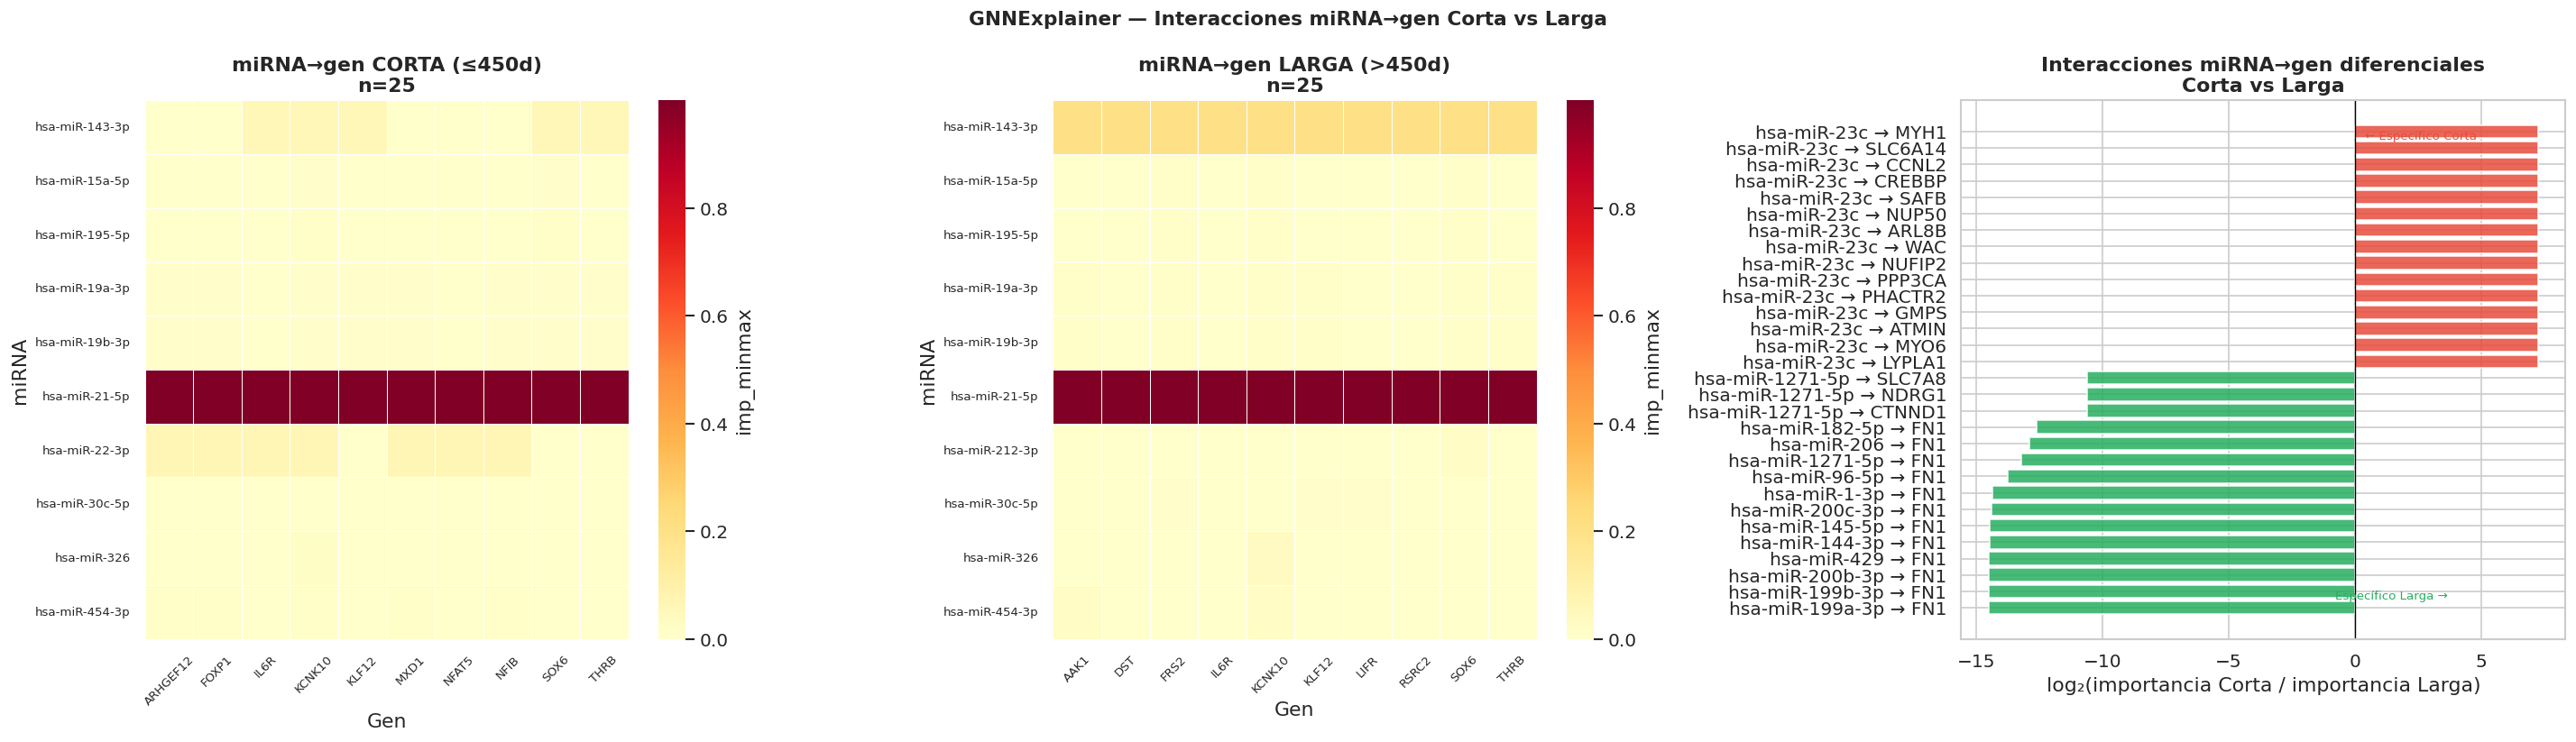

Interacciones más específicas de Supervivencia CORTA:
                  par  imp_minmax_corta  imp_minmax_larga  log2_ratio
   hsa-miR-23c → MYH1          0.000570          0.000003    7.264006
hsa-miR-23c → SLC6A14          0.000569          0.000003    7.263296
  hsa-miR-23c → CCNL2          0.000569          0.000003    7.263296
 hsa-miR-23c → CREBBP          0.000569          0.000003    7.263296
   hsa-miR-23c → SAFB          0.000569          0.000003    7.263296

Interacciones más específicas de Supervivencia LARGA:
                  par  imp_minmax_corta  imp_minmax_larga  log2_ratio
 hsa-miR-144-3p → FN1      4.456168e-08          0.023715  -14.470690
    hsa-miR-429 → FN1      1.224463e-08          0.023533  -14.504889
hsa-miR-200b-3p → FN1      1.013902e-08          0.023495  -14.505586
hsa-miR-199b-3p → FN1      6.983463e-09          0.023446  -14.507069
hsa-miR-199a-3p → FN1      6.979521e-09          0.023446  -14.507071


In [ ]:
# ── Ratio diferencial miRNA→gen Corta vs Larga ────────────────────────
def edge_mi_to_gen(results):
    df = results['edge_mi_importance'].copy()
    df['mirna_name'] = df['mirna_id'].map(mimat_to_name).fillna(df['mirna_id'])
    df['gen']        = df['isoform_id'].map(isoform_to_gene).fillna(df['isoform_id'])
    df = (df.groupby(['mirna_name','gen'])['mean_importance']
            .mean().reset_index()
            .sort_values('mean_importance', ascending=False)
            .reset_index(drop=True))
    return normalizar_importancias(df)

df_edge_corta = edge_mi_to_gen(results_corta)
df_edge_larga = edge_mi_to_gen(results_larga)
# ── Merge y ratio ─────────────────────────────────────────────────────
df_ratio_edge = df_edge_corta[['mirna_name','gen','imp_minmax']].merge(
    df_edge_larga[['mirna_name','gen','imp_minmax']],
    on=['mirna_name','gen'], suffixes=('_corta','_larga')
)
df_ratio_edge['log2_ratio'] = np.log2(
    (df_ratio_edge['imp_minmax_corta'] + 1e-6) / (df_ratio_edge['imp_minmax_larga'] + 1e-6)
)
df_ratio_edge['par'] = df_ratio_edge['mirna_name'] + ' → ' + df_ratio_edge['gen']
df_ratio_edge = df_ratio_edge.sort_values('log2_ratio', ascending=False)

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

def heatmap_edge(ax, df, titulo, top_n=10):
    top_mirnas = df.groupby('mirna_name')['imp_minmax'].sum().nlargest(top_n).index
    top_genes  = df.groupby('gen')['imp_minmax'].sum().nlargest(top_n).index
    heat = (df[df['mirna_name'].isin(top_mirnas) & df['gen'].isin(top_genes)]
            .pivot_table(index='mirna_name', columns='gen',
                         values='imp_minmax', fill_value=0))
    sns.heatmap(heat, ax=ax, cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'label': 'imp_minmax'})
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Gen'); ax.set_ylabel('miRNA')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

heatmap_edge(axes[0], df_edge_corta,
             f'miRNA→gen CORTA (≤{MEDIAN_THR:.0f}d)\nn={len(q1_val)}')
heatmap_edge(axes[1], df_edge_larga,
             f'miRNA→gen LARGA (>{MEDIAN_THR:.0f}d)\nn={len(q4_val)}')

# [2] Log2 ratio pares diferenciales
ax = axes[2]
df_plot_edge = pd.concat([
    df_ratio_edge[df_ratio_edge['log2_ratio'] >  1].head(15),
    df_ratio_edge[df_ratio_edge['log2_ratio'] < -1].tail(15)
]).drop_duplicates('par').sort_values('log2_ratio')

colors_edge = ['#27ae60' if v < 0 else '#e74c3c' for v in df_plot_edge['log2_ratio']]
ax.barh(df_plot_edge['par'], df_plot_edge['log2_ratio'],
        color=colors_edge, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('log₂(importancia Corta / importancia Larga)')
ax.set_title('Interacciones miRNA→gen diferenciales\nCorta vs Larga', fontweight='bold')
xlim = ax.get_xlim()
ax.text(xlim[1]*0.05, len(df_plot_edge)-1.5, '← Específico Corta', color='#e74c3c', fontsize=8)
ax.text(xlim[0]*0.05, 0.5,                   'Específico Larga →',  color='#27ae60', fontsize=8)

plt.suptitle('GNNExplainer — Interacciones miRNA→gen Corta vs Larga',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Conclusiones ──────────────────────────────────────────────────────
print('Interacciones más específicas de Supervivencia CORTA:')
print(df_ratio_edge.head(5)[['par','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))
print()
print('Interacciones más específicas de Supervivencia LARGA:')
print(df_ratio_edge.tail(5)[['par','imp_minmax_corta','imp_minmax_larga','log2_ratio']].to_string(index=False))

Conclusiones integradas del análisis de relaciones GNNExplainer.

In [ ]:
# ── Conclusiones integradas GNNExplainer — relaciones ─────────────────
print('═' * 65)
print('CONCLUSIONES — RELACIONES miRNA↔miRNA y miRNA→gen (GNNExplainer)')
print('═' * 65)

# ── miRNA↔miRNA global ────────────────────────────────────────────────
top_pair = df_pairs_mm.iloc[0]
print(f'\n  [miRNA↔miRNA] Par más importante (global):')
print(f'    {top_pair["mirna_A"]} ↔ {top_pair["mirna_B"]}  '
      f'(z={top_pair["imp_zscore"]:.2f}, p{top_pair["imp_percentil"]:.0f})')

mirna_freq = pd.concat([df_pairs_mm['mirna_A'], df_pairs_mm['mirna_B']]).value_counts().head(5)
print(f'\n  [miRNA↔miRNA] Hubs más conectados (global):')
for mirna, cnt in mirna_freq.items():
    print(f'    {mirna}: aparece en {cnt} pares top')

# ── miRNA↔miRNA diferencial Corta vs Larga ───────────────────────────
top_corta_mm = df_ratio_mm.iloc[0]
top_larga_mm = df_ratio_mm.iloc[-1]
print(f'\n  [miRNA↔miRNA] Par más específico de Supervivencia CORTA:')
print(f'    {top_corta_mm["par"]}  (log2ratio={top_corta_mm["log2_ratio"]:.2f})')
print(f'  [miRNA↔miRNA] Par más específico de Supervivencia LARGA:')
print(f'    {top_larga_mm["par"]}  (log2ratio={top_larga_mm["log2_ratio"]:.2f})')

# ── miRNA→gen global ──────────────────────────────────────────────────
top_mi = df_edge_mi_gen.iloc[0]
print(f'\n  [miRNA→gen] Relación más importante (global):')
print(f'    {top_mi["mirna_name"]} → {top_mi["gen"]}  '
      f'(z={top_mi["imp_zscore"]:.2f}, p{top_mi["imp_percentil"]:.0f})')

top_genes_reg = (df_edge_mi_gen.head(30)
                 .groupby('gen')['imp_minmax'].sum()
                 .sort_values(ascending=False).head(5))
print(f'\n  [miRNA→gen] Genes más regulados (suma imp_minmax top-30):')
for gen, imp in top_genes_reg.items():
    n_mirnas = df_edge_mi_gen[df_edge_mi_gen['gen'] == gen].shape[0]
    print(f'    {gen}: imp_total={imp:.3f}  regulado por {n_mirnas} miRNAs')

# ── miRNA→gen diferencial Corta vs Larga ─────────────────────────────
top_corta_mi = df_ratio_edge.iloc[0]
top_larga_mi = df_ratio_edge.iloc[-1]
print(f'\n  [miRNA→gen] Interacción más específica de Supervivencia CORTA:')
print(f'    {top_corta_mi["par"]}  (log2ratio={top_corta_mi["log2_ratio"]:.2f})')
print(f'  [miRNA→gen] Interacción más específica de Supervivencia LARGA:')
print(f'    {top_larga_mi["par"]}  (log2ratio={top_larga_mi["log2_ratio"]:.2f})')

print('\n  → Importancias normalizadas min-max. z-score = distancia a la media.')
print('  → log2ratio > 0: más importante en Corta | < 0: más importante en Larga.')
print('  → Nota: imp_total=1.000 indica saturación por dominio de miR-21-5p.')
print('    El ranking entre genes refleja nº de miRNAs reguladores, no solo importancia.')
print('═' * 65)

═════════════════════════════════════════════════════════════════
CONCLUSIONES — RELACIONES miRNA↔miRNA y miRNA→gen (GNNExplainer)
═════════════════════════════════════════════════════════════════

  [miRNA↔miRNA] Par más importante (global):
    hsa-miR-143-3p ↔ hsa-miR-7704  (z=9.71, p100)

  [miRNA↔miRNA] Hubs más conectados (global):
    hsa-miR-487b-3p: aparece en 60 pares top
    hsa-miR-758-3p: aparece en 59 pares top
    hsa-miR-337-3p: aparece en 59 pares top
    hsa-miR-409-3p: aparece en 59 pares top
    hsa-miR-127-5p: aparece en 59 pares top

  [miRNA↔miRNA] Par más específico de Supervivencia CORTA:
    hsa-miR-155-5p ↔ hsa-miR-361-3p  (log2ratio=6.65)
  [miRNA↔miRNA] Par más específico de Supervivencia LARGA:
    hsa-miR-200b-3p ↔ hsa-miR-429  (log2ratio=-10.18)

  [miRNA→gen] Relación más importante (global):
    hsa-miR-21-5p → YAP1  (z=18.80, p100)

  [miRNA→gen] Genes más regulados (suma imp_minmax top-30):
    YAP1: imp_total=1.000  regulado por 17 miRNAs
    SOX2: 

## 5. Muestras pareadas: fallecidos con muestra normal disponible

Contraste de la respuesta del modelo entre tejido tumoral y tejido sano
en los fallecidos que disponen de muestra normal pareada (barcode TCGA-12chars).
Las 44 muestras normales fueron reservadas en NB02 sin participar en el entrenamiento.
Las moléculas que el modelo considera relevantes y que además muestran
expresión diferencial entre ambos tejidos reciben atención especial en la interpretación.

Identificación de los fallecidos con muestra normal pareada
(mismo barcode TCGA de 12 caracteres).

In [ ]:
# ── Identificar fallecidos con muestra normal pareada ─────────────────
with open(barcodes_cohorte_f) as f:
    barcodes_cohorte = [l.strip() for l in f if l.strip()]

barcodes_normal_cohorte = [b for b in barcodes_cohorte if '-11' in b or '-06' in b]
barcodes_tumor_cohorte  = [b for b in barcodes_cohorte if '-01' in b]

print(f'Tumor  (-01)     : {len(barcodes_tumor_cohorte)}')
print(f'Normal (-11/-06) : {len(barcodes_normal_cohorte)}')

tumor_12 = {b[:12]: i for i, b in enumerate(barcodes_all)}
normal_12_valido = {b[:12]: i for i, b in enumerate(barcodes_normal_cohorte)
                    if i < 44}  # solo los 44 que tienen expresión en la matriz

q14_set = set(q14_indices.tolist())

pares_fallecidos = []
for bc12, tumor_idx in tumor_12.items():
    if bc12 in normal_12_valido and tumor_idx in q14_set:
        pares_fallecidos.append({
            'barcode':    bc12,
            'tumor_idx':  tumor_idx,
            'normal_idx': normal_12_valido[bc12],
            'os_time':    os_time_np[tumor_idx],
            'label':      int(labels_all[tumor_idx].item()),
            'hpv':        hpv_values[tumor_idx],
        })

df_pares_dead = pd.DataFrame(pares_fallecidos)
n_pares = len(df_pares_dead)

print(f'\nFallecidos totales          : {len(q14_indices)}')
print(f'Con muestra normal pareada  : {n_pares}')
print(f'Sin muestra normal          : {len(q14_indices) - n_pares}')
print(f'  Corta pareados: {(df_pares_dead["label"]==0).sum()}')
print(f'  Larga pareados: {(df_pares_dead["label"]==1).sum()}')
print()
print(f'OS.time (pareados): media={df_pares_dead["os_time"].mean():.0f}d  '
      f'mediana={df_pares_dead["os_time"].median():.0f}d')
print(f'HPV+ en pareados  : {int((df_pares_dead["hpv"]==1).sum())} '
      f'({(df_pares_dead["hpv"]==1).mean()*100:.1f}%)')

Tumor  (-01)     : 475
Normal (-11/-06) : 46

Fallecidos totales          : 198
Con muestra normal pareada  : 31
Sin muestra normal          : 167
  Corta pareados: 15
  Larga pareados: 16

OS.time (pareados): media=856d  mediana=453d
HPV+ en pareados  : 6 (19.4%)


Carga y verificación de las matrices de expresión normal
reservadas en NB02.

In [ ]:
# ── Cargar y verificar matrices normales ──────────────────────────────
mirna_matrix_normal_pt    = PROCESSED_DIR / 'mirna_matrix_normal.pt'
isoforma_matrix_normal_pt = PROCESSED_DIR / 'isoforma_matrix_normal.pt'

mirna_norm_all    = torch.load(mirna_matrix_normal_pt,    weights_only=False)
isoforma_norm_all = torch.load(isoforma_matrix_normal_pt, weights_only=False)

# Transponer → [n_nodos × n_muestras_normales]
mirna_norm_all    = mirna_norm_all.T     # [590 × 44]
isoforma_norm_all = isoforma_norm_all.T  # [5305 × 44]

assert mirna_norm_all.shape[0] == graph_all['mirna'].x.shape[0], \
    f'n_miRNAs no coincide: {mirna_norm_all.shape[0]} vs {graph_all["mirna"].x.shape[0]}'
assert isoforma_norm_all.shape[0] == graph_all['isoform'].x.shape[0], \
    f'n_isoformas no coincide: {isoforma_norm_all.shape[0]} vs {graph_all["isoform"].x.shape[0]}'

print('Matrices normales cargadas y verificadas')
print(f'   miRNAs    : {mirna_norm_all.shape}')
print(f'   Isoformas : {isoforma_norm_all.shape}')

# ── Extraer expresión pareada ─────────────────────────────────────────
tumor_idx_list  = df_pares_dead['tumor_idx'].tolist()
normal_idx_list = df_pares_dead['normal_idx'].tolist()

# [n_nodos × n_pares]
expr_mirna_tumor_paired  = graph_all['mirna'].x[:, tumor_idx_list].cpu().numpy()
expr_mirna_normal_paired = mirna_norm_all[:,    normal_idx_list].cpu().numpy()
expr_iso_tumor_paired    = graph_all['isoform'].x[:, tumor_idx_list].cpu().numpy()
expr_iso_normal_paired   = isoforma_norm_all[:,    normal_idx_list].cpu().numpy()

print(f'\nMatrices pareadas extraídas:')
print(f'  miRNA    tumor : {expr_mirna_tumor_paired.shape}')
print(f'  miRNA    normal: {expr_mirna_normal_paired.shape}')
print(f'  isoforma tumor : {expr_iso_tumor_paired.shape}')
print(f'  isoforma normal: {expr_iso_normal_paired.shape}')

assert expr_mirna_tumor_paired.shape == expr_mirna_normal_paired.shape, \
    ' Dimensiones tumor/normal miRNA no coinciden'
assert expr_iso_tumor_paired.shape == expr_iso_normal_paired.shape, \
    ' Dimensiones tumor/normal isoforma no coinciden'

print('\n Matrices pareadas listas para análisis diferencial')

Matrices normales cargadas y verificadas
   miRNAs    : torch.Size([590, 44])
   Isoformas : torch.Size([5305, 44])

Matrices pareadas extraídas:
  miRNA    tumor : (590, 31)
  miRNA    normal: (590, 31)
  isoforma tumor : (5305, 31)
  isoforma normal: (5305, 31)

 Matrices pareadas listas para análisis diferencial


Extracción de los IDs de nodos del grafo para alineación
con las matrices de expresión normal.

In [ ]:
# ── IDs de nodos del grafo ────────────────────────────────────────────
mirna_ids_list   = list(graph_all['mirna'].node_ids)
isoform_ids_list = list(graph_all['isoform'].node_ids)

Expresión diferencial pareada tumor vs normal mediante Wilcoxon
con corrección FDR (Benjamini-Hochberg).

In [ ]:
# ── Expresión diferencial paired: Wilcoxon tumor vs normal ───────────
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def paired_diff(expr_tumor, expr_normal, ids, name_map=None):
    """Wilcoxon pareado + FDR + log2FC para cada molécula."""
    results = []
    for i, mol_id in enumerate(ids):
        t = expr_tumor[i, :]    # [n_pares]
        n = expr_normal[i, :]   # [n_pares]
        diff = t - n
        if diff.std() < 1e-8:   # sin variación
            results.append({'id': mol_id, 'log2FC': 0, 'pval': 1.0, 'mean_tumor': t.mean(), 'mean_normal': n.mean()})
            continue
        try:
            stat, pval = wilcoxon(t, n, alternative='two-sided')
        except Exception:
            pval = 1.0
        log2fc = float(np.log2((t.mean() + 1e-6) / (n.mean() + 1e-6)))
        results.append({'id': mol_id, 'log2FC': log2fc, 'pval': float(pval),
                         'mean_tumor': float(t.mean()), 'mean_normal': float(n.mean())})

    df = pd.DataFrame(results)
    _, fdr, _, _ = multipletests(df['pval'], method='fdr_bh')
    df['FDR'] = fdr
    if name_map:
        df['name'] = df['id'].map(name_map).fillna(df['id'])
    df = df.sort_values('pval').reset_index(drop=True)
    return df

print('Calculando expresión diferencial pareada (Wilcoxon + FDR)...')
df_diff_mirna   = paired_diff(expr_mirna_tumor_paired, expr_mirna_normal_paired,
                               mirna_ids_list, mimat_to_name)
df_diff_isoform = paired_diff(expr_iso_tumor_paired,  expr_iso_normal_paired,
                               isoform_ids_list, isoform_to_gene)

sig_mirna   = df_diff_mirna[df_diff_mirna['FDR'] < 0.05]
sig_isoform = df_diff_isoform[df_diff_isoform['FDR'] < 0.05]

print(f'miRNAs  significativos (FDR<0.05): {len(sig_mirna)}')
print(f'  Sobreexpresados en tumor: {(sig_mirna["log2FC"]>0).sum()}')
print(f'  Infraexpresados en tumor: {(sig_mirna["log2FC"]<0).sum()}')
print()
print(f'Isoformas significativas (FDR<0.05): {len(sig_isoform)}')
print(f'  Sobreexpresadas en tumor: {(sig_isoform["log2FC"]>0).sum()}')
print(f'  Infraexpresadas en tumor: {(sig_isoform["log2FC"]<0).sum()}')

Calculando expresión diferencial pareada (Wilcoxon + FDR)...
miRNAs  significativos (FDR<0.05): 368
  Sobreexpresados en tumor: 236
  Infraexpresados en tumor: 132

Isoformas significativas (FDR<0.05): 1444
  Sobreexpresadas en tumor: 737
  Infraexpresadas en tumor: 707


Volcano plots de miRNAs e isoformas diferencialmente expresados
entre tejido tumoral y normal.

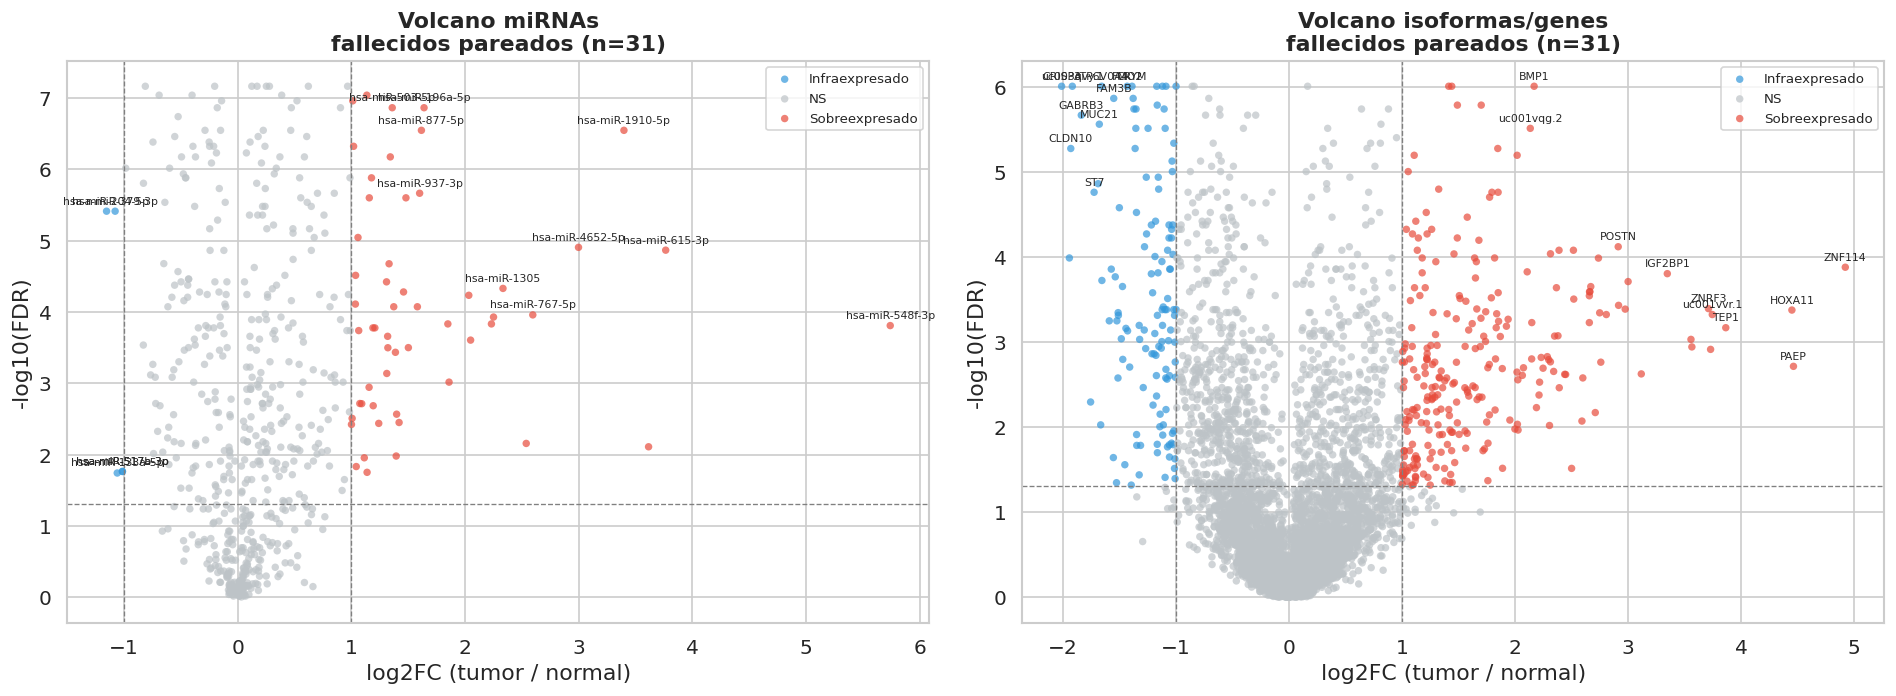

miRNAs significativos (FDR<0.05 + |log2FC|>1): 59
  Sobreexpresados en tumor: 54
  Infraexpresados en tumor: 5
  Top sobreexpresados: hsa-miR-548f-3p, hsa-miR-615-3p, hsa-miR-767-3p, hsa-miR-1910-5p, hsa-miR-4652-5p
  Top infraexpresados: hsa-miR-204-5p, hsa-miR-379-3p, hsa-miR-133a-5p, hsa-miR-517b-3p, hsa-miR-517a-3p

Isoformas significativas (FDR<0.05 + |log2FC|>1): 386
  Sobreexpresadas en tumor: 259
  Infraexpresadas en tumor: 127
  Top sobreexpresados: ZNF114, PAEP, HOXA11, TEP1, uc001vvr.1
  Top infraexpresados: CRISP3, PRR4, CLDN10, uc003qvy.1, GABRB3


In [ ]:
# ── Volcano plots: miRNA y isoformas ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def volcano(ax, df, titulo, name_col='name'):
    df = df.copy()
    df['-log10FDR'] = -np.log10(df['FDR'].clip(lower=1e-300))

    def categoria(r):
        if r['FDR'] < 0.05 and r['log2FC'] >  1: return 'Sobreexpresado'
        if r['FDR'] < 0.05 and r['log2FC'] < -1: return 'Infraexpresado'
        return 'NS'

    df['cat'] = df.apply(categoria, axis=1)
    colores = {'Sobreexpresado':'#e74c3c', 'Infraexpresado':'#3498db', 'NS':'#bdc3c7'}

    for cat, grp in df.groupby('cat'):
        ax.scatter(grp['log2FC'], grp['-log10FDR'],
                   c=colores[cat], s=20, alpha=0.7, label=cat, edgecolors='none')

    # Etiquetas: FDR<0.05 + |log2FC|>1, ordenadas por score combinado
    df_sig = df[(df['FDR'] < 0.05) & (df['log2FC'].abs() > 1)].copy()
    df_sig['score'] = df_sig['log2FC'].abs() * df_sig['-log10FDR']
    top_label = pd.concat([
    df_sig[df_sig['log2FC'] > 1].nlargest(10, 'score'),   # top 10 sobreexpresados
    df_sig[df_sig['log2FC'] < -1].nlargest(10, 'score'),  # top 10 infraexpresados
])

    for _, r in top_label.iterrows():
        lbl = r[name_col] if name_col in df.columns else r['id']
        ax.annotate(lbl, (r['log2FC'], r['-log10FDR']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points')

    ax.axvline( 1, color='gray', linestyle='--', lw=0.8)
    ax.axvline(-1, color='gray', linestyle='--', lw=0.8)
    ax.axhline(-np.log10(0.05), color='gray', linestyle='--', lw=0.8)
    ax.set_xlabel('log2FC (tumor / normal)')
    ax.set_ylabel('-log10(FDR)')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)

volcano(axes[0], df_diff_mirna,
        f'Volcano miRNAs\nfallecidos pareados (n={n_pares})', 'name')
volcano(axes[1], df_diff_isoform,
        f'Volcano isoformas/genes\nfallecidos pareados (n={n_pares})', 'name')

plt.tight_layout()
plt.show()

# ── Resumen con criterio FDR<0.05 + |log2FC|>1 ───────────────────────
sig_mirna_strict   = df_diff_mirna[(df_diff_mirna['FDR'] < 0.05) &
                                    (df_diff_mirna['log2FC'].abs() > 1)]
sig_isoform_strict = df_diff_isoform[(df_diff_isoform['FDR'] < 0.05) &
                                      (df_diff_isoform['log2FC'].abs() > 1)]

print(f'miRNAs significativos (FDR<0.05 + |log2FC|>1): {len(sig_mirna_strict)}')
print(f'  Sobreexpresados en tumor: {(sig_mirna_strict["log2FC"]>0).sum()}')
print(f'  Infraexpresados en tumor: {(sig_mirna_strict["log2FC"]<0).sum()}')
print(f'  Top sobreexpresados: {", ".join(sig_mirna_strict[sig_mirna_strict["log2FC"]>0].nlargest(5,"log2FC")["name"].tolist())}')
print(f'  Top infraexpresados: {", ".join(sig_mirna_strict[sig_mirna_strict["log2FC"]<0].nsmallest(5,"log2FC")["name"].tolist())}')
print()
print(f'Isoformas significativas (FDR<0.05 + |log2FC|>1): {len(sig_isoform_strict)}')
print(f'  Sobreexpresadas en tumor: {(sig_isoform_strict["log2FC"]>0).sum()}')
print(f'  Infraexpresadas en tumor: {(sig_isoform_strict["log2FC"]<0).sum()}')
print(f'  Top sobreexpresados: {", ".join(sig_isoform_strict[sig_isoform_strict["log2FC"]>0].nlargest(5,"log2FC")["name"].tolist())}')
print(f'  Top infraexpresados: {", ".join(sig_isoform_strict[sig_isoform_strict["log2FC"]<0].nsmallest(5,"log2FC")["name"].tolist())}')

GNNExplainer sobre los fallecidos pareados (tejido tumoral)
para obtener importancias específicas de este subgrupo.

In [ ]:
# ── GNNExplainer sobre fallecidos pareados (tumor) ────────────────────
tumor_idx_q14  = df_pares_dead['tumor_idx'].tolist()
normal_idx_q14 = df_pares_dead['normal_idx'].tolist()

print(f'Fallecidos pareados: {len(tumor_idx_q14)}')
print(f'  Corta: {sum(labels_all[ti].item()==0 for ti in tumor_idx_q14)}')
print(f'  Larga: {sum(labels_all[ti].item()==1 for ti in tumor_idx_q14)}')

print('\nGNNExplainer sobre pareados (tumor)...')
results_paired_tumor = run_gnnexplainer(
    model           = best_model,
    data            = graph_all,
    patient_indices = tumor_idx_q14,
    hpv             = hpv_tensor,
)

df_paired_mirna = results_paired_tumor['mirna_importance'].copy()
df_paired_iso   = results_paired_tumor['isoform_importance'].copy()
df_paired_mirna['mirna_name'] = df_paired_mirna['mirna_id'].map(mimat_to_name).fillna(df_paired_mirna['mirna_id'])
df_paired_iso['gen']          = df_paired_iso['isoform_id'].map(isoform_to_gene).fillna(df_paired_iso['isoform_id'])
df_paired_mirna = normalizar_importancias(df_paired_mirna)
df_paired_iso   = normalizar_importancias(df_paired_iso)

print('\nTop 10 miRNAs más importantes (fallecidos pareados):')
print(df_paired_mirna[['mirna_name','imp_minmax','imp_zscore']].head(10).to_string(index=False))
print()
print('Top 10 genes más importantes (fallecidos pareados):')
print(df_paired_iso[['gen','imp_minmax','imp_zscore']].head(10).to_string(index=False))

Fallecidos pareados: 31
  Corta: 15
  Larga: 16

GNNExplainer sobre pareados (tumor)...

Top 10 miRNAs más importantes (fallecidos pareados):
       mirna_name  imp_minmax  imp_zscore
    hsa-miR-21-5p    1.000000   18.259313
   hsa-miR-143-3p    0.871983   15.913764
  hsa-miR-203a-3p    0.018198    0.270538
     hsa-miR-7704    0.013436    0.183285
   hsa-miR-431-5p    0.009289    0.107308
hsa-miR-103a-2-5p    0.008449    0.091918
      hsa-miR-326    0.007704    0.078264
    hsa-miR-22-3p    0.006981    0.065023
  hsa-miR-500a-5p    0.006022    0.047445
  hsa-miR-500b-5p    0.006019    0.047381

Top 10 genes más importantes (fallecidos pareados):
       gen  imp_minmax  imp_zscore
     KRT14    1.000000   55.221766
     GPNMB    0.754386   41.651767
     KRT19    0.332612   18.349119
     KRT13    0.196436   10.825503
     ADAM6    0.086563    4.755121
     IGHG1    0.080891    4.441696
     SPRR3    0.059428    3.255921
       PI3    0.034261    1.865480
uc001ysf.2    0.031102    1.

Cruce de la expresión diferencial con la importancia del modelo
para miRNAs: candidatos con doble evidencia.

In [ ]:
# ── Cruce expresión diferencial × importancia modelo (pareados) ───────
# miRNAs/genes que:
#   - Están diferencialmente expresados tumor vs normal (Wilcoxon FDR<0.05)
#   - Y el modelo les asigna importancia alta en los fallecidos pareados

df_cross_mirna = df_diff_mirna[df_diff_mirna['FDR'] < 0.05].merge(
    df_paired_mirna[['mirna_id','mirna_name','imp_minmax','imp_zscore']],
    left_on='id', right_on='mirna_id', how='inner'
).sort_values('imp_minmax', ascending=False)

df_cross_iso = df_diff_isoform[df_diff_isoform['FDR'] < 0.05].merge(
    df_paired_iso[['isoform_id','gen','imp_minmax','imp_zscore']],
    left_on='id', right_on='isoform_id', how='inner'
).sort_values('imp_minmax', ascending=False)

print(f'miRNAs dif. expresados Y importantes para el modelo: {len(df_cross_mirna)}')
print(df_cross_mirna[['mirna_name','log2FC','FDR','imp_minmax','imp_zscore']].head(15).to_string(index=False))
print()
print(f'Genes dif. expresados Y importantes para el modelo: {len(df_cross_iso)}')
print(df_cross_iso[['gen','log2FC','FDR','imp_minmax','imp_zscore']].head(15).to_string(index=False))

miRNAs dif. expresados Y importantes para el modelo: 368
    mirna_name    log2FC          FDR  imp_minmax  imp_zscore
 hsa-miR-21-5p  0.123701 6.868504e-08    1.000000   18.259313
hsa-miR-143-3p -0.058355 1.673872e-03    0.871983   15.913764
hsa-miR-431-5p  0.811648 8.474430e-05    0.009289    0.107308
 hsa-miR-22-3p  0.032668 1.449934e-02    0.006981    0.065023
hsa-miR-671-5p  0.903967 1.373701e-07    0.005213    0.032626
hsa-miR-212-3p  0.218965 1.926382e-03    0.005073    0.030058
hsa-miR-411-5p -0.432840 3.465953e-05    0.005065    0.029916
hsa-miR-758-5p -0.170373 3.277263e-02    0.004780    0.024696
hsa-miR-454-3p  0.487149 1.837325e-05    0.004631    0.021950
hsa-miR-139-3p -0.553835 3.480042e-07    0.004525    0.020021
hsa-miR-576-5p  0.178475 1.235811e-02    0.004037    0.011076
hsa-miR-195-5p -0.478207 1.162362e-06    0.003434    0.000028
hsa-miR-19a-3p  0.284066 5.006405e-04    0.002925   -0.009304
hsa-miR-423-3p  0.240561 3.319158e-06    0.002102   -0.024375
hsa-miR-15a-5

Cruce de la expresión diferencial con la importancia del modelo
para isoformas: candidatos con doble evidencia.

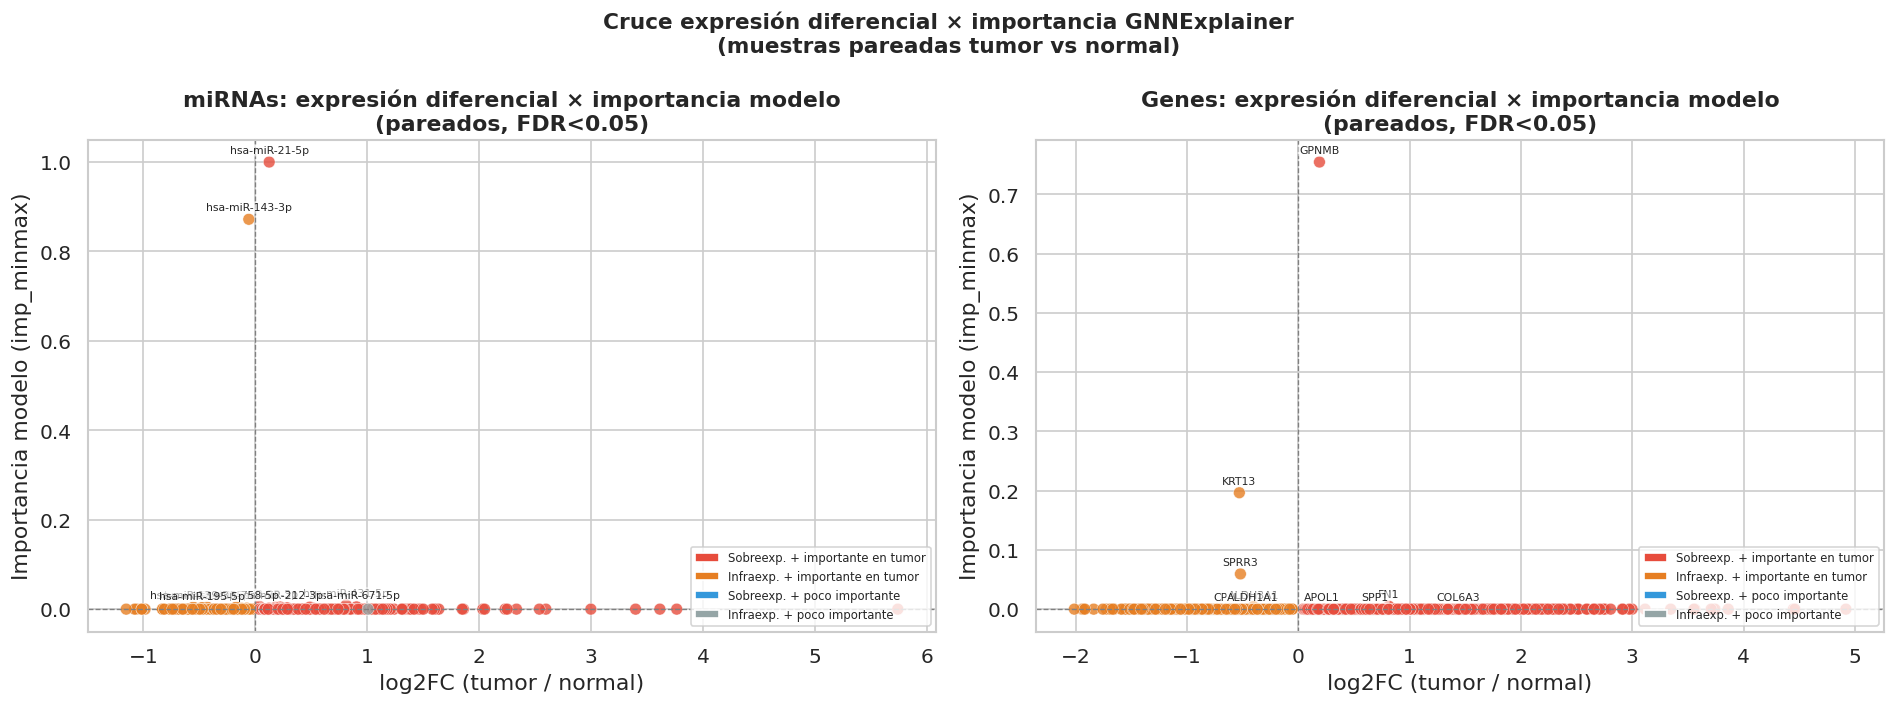

miRNAs sobreexpresados en tumor Y más importantes para el modelo:
    mirna_name   log2FC          FDR  imp_minmax  imp_zscore
 hsa-miR-21-5p 0.123701 6.868504e-08    1.000000   18.259313
hsa-miR-431-5p 0.811648 8.474430e-05    0.009289    0.107308
 hsa-miR-22-3p 0.032668 1.449934e-02    0.006981    0.065023
hsa-miR-671-5p 0.903967 1.373701e-07    0.005213    0.032626
hsa-miR-212-3p 0.218965 1.926382e-03    0.005073    0.030058

Genes sobreexpresados en tumor Y más importantes para el modelo:
   gen   log2FC          FDR  imp_minmax  imp_zscore
 GPNMB 0.188804 1.283021e-04    0.754386   41.651767
   FN1 0.811550 2.760961e-06    0.004978    0.247564
 APOL1 0.208816 7.100315e-03    0.000021   -0.026276
COL6A3 1.437767 9.881333e-07    0.000008   -0.026977
  SPP1 0.688268 5.328169e-06    0.000004   -0.027206


In [ ]:
# ── Cruce expresión diferencial × importancia modelo (pareados) ───────
df_cross_mirna = df_diff_mirna[df_diff_mirna['FDR'] < 0.05].merge(
    df_paired_mirna[['mirna_id','mirna_name','imp_minmax','imp_zscore']],
    left_on='id', right_on='mirna_id', how='inner'
).sort_values('imp_minmax', ascending=False)

df_cross_iso = df_diff_isoform[df_diff_isoform['FDR'] < 0.05].merge(
    df_paired_iso[['isoform_id','gen','imp_minmax','imp_zscore']],
    left_on='id', right_on='isoform_id', how='inner'
).sort_values('imp_minmax', ascending=False)

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def scatter_cross(ax, df, x_col, y_col, label_col, titulo):
    colors = []
    for _, r in df.iterrows():
        if r[x_col] > 0 and r[y_col] > 0:  colors.append('#e74c3c')  # sobre + importante
        elif r[x_col] < 0 and r[y_col] > 0: colors.append('#e67e22')  # infra + importante
        elif r[x_col] > 0 and r[y_col] < 0: colors.append('#3498db')  # sobre + poco importante
        else:                                colors.append('#95a5a6')  # infra + poco importante

    ax.scatter(df[x_col], df[y_col],
               c=colors, s=50, alpha=0.8, edgecolors='white', lw=0.3)
    ax.axvline(0, color='gray', lw=0.8, linestyle='--')
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')

    # Top 5 cuadrante más interesante: sobreexpresado + importante
    df_top = pd.concat([
        df[(df[x_col] > 0) & (df[y_col] > 0)].nlargest(5, y_col),
        df[(df[x_col] < 0) & (df[y_col] > 0)].nlargest(5, y_col),
    ]).drop_duplicates()

    for _, r in df_top.iterrows():
        ax.annotate(r[label_col], (r[x_col], r[y_col]),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, lw=0))

    ax.set_xlabel('log2FC (tumor / normal)')
    ax.set_ylabel('Importancia modelo (imp_minmax)')
    ax.set_title(titulo, fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Sobreexp. + importante en tumor'),
        Patch(facecolor='#e67e22', label='Infraexp. + importante en tumor'),
        Patch(facecolor='#3498db', label='Sobreexp. + poco importante'),
        Patch(facecolor='#95a5a6', label='Infraexp. + poco importante'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='lower right')

name_col   = 'mirna_name_y' if 'mirna_name_y' in df_cross_mirna.columns else 'mirna_name'
name_col_g = 'gen_y'        if 'gen_y'        in df_cross_iso.columns   else 'gen'

scatter_cross(axes[0], df_cross_mirna, 'log2FC', 'imp_minmax',
              name_col, f'miRNAs: expresión diferencial × importancia modelo\n(pareados, FDR<0.05)')
scatter_cross(axes[1], df_cross_iso,   'log2FC', 'imp_minmax',
              name_col_g, f'Genes: expresión diferencial × importancia modelo\n(pareados, FDR<0.05)')

plt.suptitle('Cruce expresión diferencial × importancia GNNExplainer\n(muestras pareadas tumor vs normal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Conclusiones ──────────────────────────────────────────────────────
print('miRNAs sobreexpresados en tumor Y más importantes para el modelo:')
top_m = df_cross_mirna[(df_cross_mirna['log2FC'] > 0)].head(5)
print(top_m[[name_col,'log2FC','FDR','imp_minmax','imp_zscore']].to_string(index=False))
print()
print('Genes sobreexpresados en tumor Y más importantes para el modelo:')
top_g = df_cross_iso[(df_cross_iso['log2FC'] > 0)].head(5)
print(top_g[[name_col_g,'log2FC','FDR','imp_minmax','imp_zscore']].to_string(index=False))

Conclusiones finales del análisis de muestras pareadas.

In [ ]:
# ── Conclusiones finales muestras pareadas ────────────────────────────
print('═' * 65)
print('CONCLUSIONES — MUESTRAS PAREADAS FALLECIDOS (tumor vs normal)')
print('═' * 65)
print(f'  Pares analizados: {n_pares} (Corta: {(df_pares_dead["label"]==0).sum()} | Larga: {(df_pares_dead["label"]==1).sum()})')
print()

# ── Expresión diferencial ─────────────────────────────────────────────
print(f'  Expresión diferencial (Wilcoxon, FDR<0.05 + |log2FC|>1):')
print(f'    miRNAs significativos : {len(sig_mirna_strict)} ({(sig_mirna_strict["log2FC"]>0).sum()} sobre, {(sig_mirna_strict["log2FC"]<0).sum()} infra)')
print(f'    Genes  significativos : {len(sig_isoform_strict)} ({(sig_isoform_strict["log2FC"]>0).sum()} sobre, {(sig_isoform_strict["log2FC"]<0).sum()} infra)')
print()

# ── Candidatos consenso miRNA ─────────────────────────────────────────
if len(df_cross_mirna) > 0:
    name_col = 'mirna_name_y' if 'mirna_name_y' in df_cross_mirna.columns else 'mirna_name'

    top_sobre = df_cross_mirna[df_cross_mirna['log2FC'] > 0].head(5)
    top_infra = df_cross_mirna[df_cross_mirna['log2FC'] < 0].head(5)

    print('  miRNAs sobreexpresados en tumor Y importantes para el modelo:')
    for _, r in top_sobre.iterrows():
        n = r[name_col]
        print(f'    {n:<25} log2FC={r["log2FC"]:+.2f}  FDR={r["FDR"]:.2e}  imp_minmax={r["imp_minmax"]:.3f}  z={r["imp_zscore"]:.1f}')

    print()
    print('  miRNAs infraexpresados en tumor Y importantes para el modelo:')
    for _, r in top_infra.iterrows():
        n = r[name_col]
        print(f'    {n:<25} log2FC={r["log2FC"]:+.2f}  FDR={r["FDR"]:.2e}  imp_minmax={r["imp_minmax"]:.3f}  z={r["imp_zscore"]:.1f}')

print()

# ── Candidatos consenso genes ─────────────────────────────────────────
if len(df_cross_iso) > 0:
    name_col_g = 'gen_y' if 'gen_y' in df_cross_iso.columns else 'gen'

    top_genes_sobre = df_cross_iso[df_cross_iso['log2FC'] > 0].head(5)
    top_genes_infra = df_cross_iso[df_cross_iso['log2FC'] < 0].head(5)

    print('  Genes sobreexpresados en tumor Y importantes para el modelo:')
    for _, r in top_genes_sobre.iterrows():
        g = r[name_col_g]
        print(f'    {g:<20} log2FC={r["log2FC"]:+.2f}  FDR={r["FDR"]:.2e}  imp_minmax={r["imp_minmax"]:.3f}  z={r["imp_zscore"]:.1f}')

    print()
    print('  Genes infraexpresados en tumor Y importantes para el modelo:')
    for _, r in top_genes_infra.iterrows():
        g = r[name_col_g]
        print(f'    {g:<20} log2FC={r["log2FC"]:+.2f}  FDR={r["FDR"]:.2e}  imp_minmax={r["imp_minmax"]:.3f}  z={r["imp_zscore"]:.1f}')

print()
print('  → Candidatos consenso (doble evidencia estadística + modelo):')
print('    Expresión diferencial validada por Wilcoxon pareado (FDR<0.05)')
print('    e importancia confirmada por GNNExplainer sobre fallecidos.')
print('═' * 65)

═════════════════════════════════════════════════════════════════
CONCLUSIONES — MUESTRAS PAREADAS FALLECIDOS (tumor vs normal)
═════════════════════════════════════════════════════════════════
  Pares analizados: 31 (Corta: 15 | Larga: 16)

  Expresión diferencial (Wilcoxon, FDR<0.05 + |log2FC|>1):
    miRNAs significativos : 59 (54 sobre, 5 infra)
    Genes  significativos : 386 (259 sobre, 127 infra)

  miRNAs sobreexpresados en tumor Y importantes para el modelo:
    hsa-miR-21-5p             log2FC=+0.12  FDR=6.87e-08  imp_minmax=1.000  z=18.3
    hsa-miR-431-5p            log2FC=+0.81  FDR=8.47e-05  imp_minmax=0.009  z=0.1
    hsa-miR-22-3p             log2FC=+0.03  FDR=1.45e-02  imp_minmax=0.007  z=0.1
    hsa-miR-671-5p            log2FC=+0.90  FDR=1.37e-07  imp_minmax=0.005  z=0.0
    hsa-miR-212-3p            log2FC=+0.22  FDR=1.93e-03  imp_minmax=0.005  z=0.0

  miRNAs infraexpresados en tumor Y importantes para el modelo:
    hsa-miR-143-3p            log2FC=-0.06  FDR=1.67

## 6. Guardado del modelo y tabla resumen

Guardado del estado del mejor modelo, configuración de hiperparámetros Optuna
y tabla resumen con métricas por fold.

Guardado del estado del mejor modelo y configuración de hiperparámetros.

In [ ]:
model_path = Path('data/processed_hnsc/best_model_hnsc_v8.pt')

# Nombres de columna tras el merge pueden variar
nc = 'mirna_name_y' if 'mirna_name_y' in df_cross_mirna.columns else 'mirna_name'
ng = 'gen_y'        if 'gen_y'        in df_cross_iso.columns   else 'gen'

torch.save({
    'model_state_dict': best_state,
    'config_params': {
        'num_mirna':      best_config.num_mirna,
        'num_mrna':       best_config.num_mrna,
        'num_patients':   best_config.num_patients,
        'hidden_dim':     best_config.hidden_dim,
        'heads':          best_config.heads,
        'os_head_dim':    best_config.os_head_dim,
        'dropout':        best_config.dropout,
        'expr_embed_dim': best_config.expr_embed_dim,
        'hpv_embed_dim':  best_config.hpv_embed_dim,
    },
    'optuna_best_params':        best_params,
    'fold_metrics':              fold_metrics,
    'best_fold_idx':             best_fold_idx,
    'median_threshold':          MEDIAN_THR,
    'classification_threshold':  BEST_THRESHOLD,
    'top_mirnas_global':         df_mirna_imp[['mirna_name','imp_minmax','imp_zscore']].head(20).to_dict(),
    'top_genes_global':          df_isoform_imp[['gen','imp_minmax','imp_zscore']].head(20).to_dict(),
    'candidatos_consenso_mirna': df_cross_mirna[[nc,'log2FC','FDR','imp_minmax']].head(10).to_dict(),
    'candidatos_consenso_gen':   df_cross_iso[[ng,'log2FC','FDR','imp_minmax']].head(10).to_dict(),
}, model_path)

print(f' Modelo guardado: {model_path}')
print(f'   Mediana umbral OS    : {MEDIAN_THR:.0f}d')
print(f'   Umbral clasificación : {BEST_THRESHOLD:.4f}  (Youden)')
print(f'   AUC media K-Fold     : {np.mean([m["val_auc"] for m in fold_metrics]):.3f} ± {np.std([m["val_auc"] for m in fold_metrics]):.3f}')
print(f'   miRNA top global     : {df_mirna_imp.iloc[0]["mirna_name"]} (z={df_mirna_imp.iloc[0]["imp_zscore"]:.1f})')
print(f'   Gen top global       : {df_isoform_imp.iloc[0]["gen"]} (z={df_isoform_imp.iloc[0]["imp_zscore"]:.1f})')
print(f'   Candidato consenso 1 : {df_cross_mirna.iloc[0][nc] if len(df_cross_mirna)>0 else "N/A"}')

✅ Modelo guardado: data/processed_hnsc/best_model_hnsc_v8.pt
   Mediana umbral OS    : 450d
   Umbral clasificación : 0.4902  (Youden)
   AUC media K-Fold     : 0.648 ± 0.043
   miRNA top global     : hsa-miR-21-5p (z=23.4)
   Gen top global       : KRT14 (z=65.8)
   Candidato consenso 1 : hsa-miR-21-5p


Tabla resumen con métricas por fold y configuración final.

In [ ]:
# ── Tabla resumen final ───────────────────────────────────────────────
aucs = [m['val_auc'] for m in fold_metrics]

print('═' * 70)
print('RESUMEN FINAL — SupraGraphNet v8 | TCGA-HNSC')
print('═' * 70)

# ── Rendimiento ───────────────────────────────────────────────────────
print('\n  [RENDIMIENTO]')
print(f'   Cohorte          : 474 pacientes TCGA-HNSC | 198 fallecidos')
print(f'   Target           : clasificación binaria por mediana OS.time')
print(f'   Umbral mediana   : {MEDIAN_THR:.0f}d  (Corta ≤{MEDIAN_THR:.0f}d | Larga >{MEDIAN_THR:.0f}d)')
print(f'   Loss             : Focal Loss (γ={TRAIN_FOCAL_GAMMA:.3f}) + Label Smoothing ({TRAIN_LABEL_SMOOTHING:.3f})')
print()
print(f'   — Métricas K-Fold (AUC) —')
print(f'   AUC media        : {np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
print(f'   Mejor fold AUC   : {max(aucs):.3f}  (Fold {best_fold_idx})')
print()
print(f'   — Métricas con umbral Youden {BEST_THRESHOLD:.4f} (Fold {best_fold_idx}) —')
best_m     = fold_metrics[best_fold_idx - 1]
preds_cal  = (best_m['val_probs'] >= BEST_THRESHOLD).astype(int)
labels_cal = best_m['val_labels'].astype(int)
from sklearn.metrics import f1_score, recall_score, precision_score
f1_macro_cal  = f1_score(labels_cal, preds_cal, average='macro',  zero_division=0)
rec_corta_cal = recall_score(labels_cal, preds_cal, pos_label=0,  zero_division=0)
rec_larga_cal = recall_score(labels_cal, preds_cal, pos_label=1,  zero_division=0)
accuracy_cal  = (preds_cal == labels_cal).mean()
print(f'   AUC              : {best_m["val_auc"]:.3f}  (invariante al umbral)')
print(f'   F1 macro         : {f1_macro_cal:.3f}')
print(f'   Accuracy         : {accuracy_cal:.3f}')
print(f'   Recall Corta     : {rec_corta_cal:.3f}')
print(f'   Recall Larga     : {rec_larga_cal:.3f}')

══════════════════════════════════════════════════════════════════════
RESUMEN FINAL — SupraGraphNet v8 | TCGA-HNSC
══════════════════════════════════════════════════════════════════════

  [RENDIMIENTO]
   Cohorte          : 474 pacientes TCGA-HNSC | 198 fallecidos
   Target           : clasificación binaria por mediana OS.time
   Umbral mediana   : 450d  (Corta ≤450d | Larga >450d)
   Loss             : Focal Loss (γ=1.615) + Label Smoothing (0.084)

   — Métricas K-Fold (AUC) —
   AUC media        : 0.648 ± 0.043
   Mejor fold AUC   : 0.714  (Fold 1)

   — Métricas con umbral Youden 0.4902 (Fold 1) —
   AUC              : 0.714  (invariante al umbral)
   F1 macro         : 0.718
   Accuracy         : 0.720
   Recall Corta     : 0.800
   Recall Larga     : 0.640


Tabla resumen adicional con estadísticos globales del experimento.

In [ ]:
# ── Tabla resumen final ───────────────────────────────────────────────
aucs = [m['val_auc'] for m in fold_metrics]
f1s  = [m['val_f1']  for m in fold_metrics]

print('═' * 70)
print('RESUMEN FINAL  SupraGraphNet | TCGA-HNSC')
print('═' * 70)

# ── GNNExplainer — nodos ──────────────────────────────────────────────
print('\n  [GNNExplainer — IMPORTANCIA DE NODOS]')
print('   Top 5 miRNAs (global):')
for _, r in df_mirna_imp.head(5).iterrows():
    print(f'     {r["mirna_name"]:<25} z={r["imp_zscore"]:>6.2f}')
print('   Top 5 genes (global):')
for _, r in df_isoform_imp.head(5).iterrows():
    print(f'     {r["gen"]:<20} z={r["imp_zscore"]:>6.2f}')

print('\n   Top 3 miRNAs específicos Corta:')
for _, r in df_ratio.head(3).iterrows():
    print(f'     {r["mirna_name"]:<25} log2ratio={r["log2_ratio"]:+.2f}')
print('   Top 3 miRNAs específicos Larga:')
for _, r in df_ratio.tail(3).iterrows():
    print(f'     {r["mirna_name"]:<25} log2ratio={r["log2_ratio"]:+.2f}')

# ── GNNExplainer — relaciones ─────────────────────────────────────────
print('\n  [GNNExplainer — RELACIONES]')
print('   Par miRNA↔miRNA más importante:')
top_mm = df_pairs_mm.iloc[0]
print(f'     {top_mm["mirna_A"]} ↔ {top_mm["mirna_B"]}  (z={top_mm["imp_zscore"]:.2f})')
print('   Top 3 hubs miRNA↔miRNA:')
hubs = pd.concat([df_pairs_mm['mirna_A'], df_pairs_mm['mirna_B']]).value_counts().head(3)
for mirna, cnt in hubs.items():
    print(f'     {mirna:<25} aparece en {cnt} pares top')
print('   Relación miRNA→gen más importante:')
top_mi = df_edge_mi_gen.iloc[0]
print(f'     {top_mi["mirna_name"]} → {top_mi["gen"]}  (z={top_mi["imp_zscore"]:.2f})')
print('   Top 3 interacciones específicas Corta:')
for _, r in df_ratio_edge.head(3).iterrows():
    print(f'     {r["par"]:<45} log2ratio={r["log2_ratio"]:+.2f}')
print('   Top 3 interacciones específicas Larga:')
for _, r in df_ratio_edge.tail(3).iterrows():
    print(f'     {r["par"]:<45} log2ratio={r["log2_ratio"]:+.2f}')

# ── Muestras pareadas ─────────────────────────────────────────────────
print('\n  [MUESTRAS PAREADAS TUMOR vs NORMAL]')
print(f'   Pares analizados : {n_pares} (Corta: {(df_pares_dead["label"]==0).sum()} | Larga: {(df_pares_dead["label"]==1).sum()})')
print(f'   miRNAs sig. (FDR<0.05 + |log2FC|>1): {len(sig_mirna_strict)} ({(sig_mirna_strict["log2FC"]>0).sum()} sobre, {(sig_mirna_strict["log2FC"]<0).sum()} infra)')
print(f'   Genes  sig. (FDR<0.05 + |log2FC|>1): {len(sig_isoform_strict)} ({(sig_isoform_strict["log2FC"]>0).sum()} sobre, {(sig_isoform_strict["log2FC"]<0).sum()} infra)')

name_col   = 'mirna_name_y' if 'mirna_name_y' in df_cross_mirna.columns else 'mirna_name'
name_col_g = 'gen_y'        if 'gen_y'        in df_cross_iso.columns   else 'gen'

print('\n   Candidatos consenso miRNA (expresión + modelo):')
for _, r in df_cross_mirna[
    (df_cross_mirna['log2FC'] > 0) &
    (df_cross_mirna['imp_minmax'] > 0.01)
].head(5).iterrows():
    print(f'     {r[name_col]:<25} log2FC={r["log2FC"]:+.2f}  FDR={r["FDR"]:.2e}  imp_minmax={r["imp_minmax"]:.3f}')

print('\n   Candidatos consenso gen (expresión + modelo):')
for _, r in df_cross_iso[
    (df_cross_iso['log2FC'] > 0) &
    (df_cross_iso['imp_minmax'] > 0.01)
].head(5).iterrows():
    print(f'     {r[name_col_g]:<20} log2FC={r["log2FC"]:+.2f}  FDR={r["FDR"]:.2e}  imp_minmax={r["imp_minmax"]:.3f}')

print()
print('═' * 70)

══════════════════════════════════════════════════════════════════════
RESUMEN FINAL — SupraGraphNet v8 | TCGA-HNSC
══════════════════════════════════════════════════════════════════════

  [GNNExplainer — IMPORTANCIA DE NODOS]
   Top 5 miRNAs (global):
     hsa-miR-21-5p             z= 23.35
     hsa-miR-203a-3p           z=  5.27
     hsa-miR-143-3p            z=  3.08
     hsa-miR-7704              z=  0.95
     hsa-miR-22-3p             z=  0.69
   Top 5 genes (global):
     KRT14                z= 65.82
     KRT13                z= 20.37
     NTS                  z= 14.32
     GPNMB                z= 12.81
     IGHG1                z=  7.94

   Top 3 miRNAs específicos Corta:
     hsa-miR-23c               log2ratio=+7.26
     hsa-miR-22-3p             log2ratio=+5.67
     hsa-miR-155-5p            log2ratio=+5.15
   Top 3 miRNAs específicos Larga:
     hsa-miR-20b-3p            log2ratio=-8.91
     hsa-miR-133a-5p           log2ratio=-9.65
     hsa-miR-1271-5p           log2ratio